<!-- ======================================== -->
<!--          AI辅助材料设计课程报告        -->
<!-- ======================================== -->

<div align="center">

# **AI辅助材料设计**
## **期末实验报告**

---

| **姓名** | 林嘉馨 |
|----------|------------|
| **学号** | 23302040   |
| **专业** | 材料科学与工程 |
| **学院** | 材料学院 |
| **日期** | 2026-01-17 |

---

<div align="center">
    
## 摘要

本实验围绕材料内聚能（Ec）的预测问题，系统比较了多种机器学习模型在材料性能建模任务中的表现。基于给定材料数据集，对特征进行了统计分析与规范化处理，以降低不同物理量量纲差异对模型训练过程的影响。在此基础上，分别构建了线性模型、基于决策树的集成学习模型以及多层感知机（MLP）神经网络模型，并采用交叉验证与独立测试集相结合的方式对模型预测性能进行评估。实验结果表明，不同模型在预测精度与泛化能力方面存在差异，其中非线性模型能够更有效地刻画材料特征与内聚能之间的复杂映射关系，神经网络模型在综合预测性能方面表现较为突出。进一步分析发现，合理的特征标准化与正则化策略有助于提升模型训练的稳定性与泛化能力。实验结果验证了机器学习方法在材料内聚能预测中的可行性与有效性，为数据驱动的材料性能评估与设计提供了有益参考。

**关键词**:材料内聚能；机器学习；神经网络；特征工程；性能预测



## 1. （2分）下载数据文件。使用训练数据创建一个PandasDataFrame。

In [1]:
# ============================================
# 任务1: 下载数据文件并创建DataFrame
# ============================================

import pandas as pd
import numpy as np

# 加载训练数据
train_df = pd.read_csv('train.csv')

# 加载测试数据
test_df = pd.read_csv('test.csv')

# 加载预测集
predict_df = pd.read_csv('predict.csv')

# 加载元素属性数据
element_properties_df = pd.read_csv('element_properties.csv')

print("训练集形状:", train_df.shape)
print("\n训练集前5行:")
print(train_df.head())

print("\n训练集列名:", train_df.columns.tolist())

print("\n数据信息:")
print(train_df.info())

print("\n目标变量统计:")
print(train_df['cohesive_energy_per_atom'].describe())

训练集形状: (343782, 4)

训练集前5行:
   Unnamed: 0                  matpes_id formula_pretty  \
0           0                  mp-862690             Ac   
1           1                 mp-1183069             Ac   
2           2                   mp-10018             Ac   
3           3                 mp-1183057             Ac   
4           4  matpes-20240214_1183069_3             Ac   

   cohesive_energy_per_atom  
0                 -3.549690  
1                 -3.541488  
2                 -3.529483  
3                 -3.526954  
4                 -3.445399  

训练集列名: ['Unnamed: 0', 'matpes_id', 'formula_pretty', 'cohesive_energy_per_atom']

数据信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343782 entries, 0 to 343781
Data columns (total 4 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                343782 non-null  int64  
 1   matpes_id                 343782 non-null  object 
 2   formula_p

## 2. （3分）绘制训练数据中Ec的直方图。

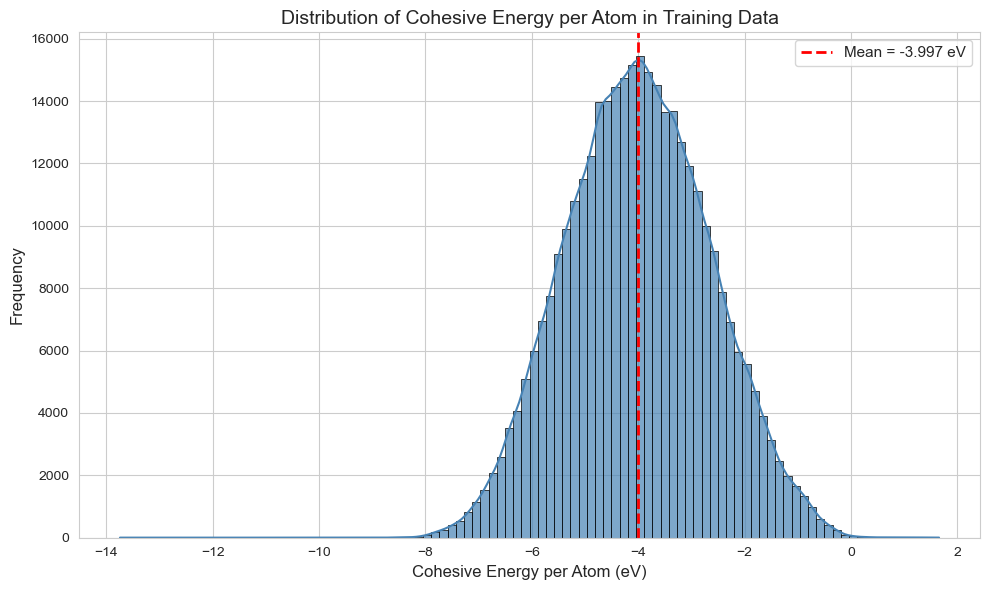

Ec统计信息:
样本数: 343782
均值: -3.9971 eV
中位数: -4.0099 eV
标准差: 1.3479 eV
最小值: -13.7408 eV
最大值: 1.6570 eV


In [2]:
# ============================================
# 任务2: 绘制训练数据中Ec的直方图
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# 设置seaborn样式
sns.set_style("whitegrid")

# 创建图形
plt.figure(figsize=(10, 6))

# 使用seaborn绘制直方图
sns.histplot(data=train_df, 
             x='cohesive_energy_per_atom', 
             bins=100, 
             kde=True,  # 添加核密度估计曲线
             color='steelblue',
             edgecolor='black',
             alpha=0.7)

# 添加均值线
mean_value = train_df['cohesive_energy_per_atom'].mean()
plt.axvline(mean_value, 
            color='red', 
            linestyle='--', 
            linewidth=2, 
            label=f'Mean = {mean_value:.3f} eV')

# 设置标题和标签
plt.xlabel('Cohesive Energy per Atom (eV)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Cohesive Energy per Atom in Training Data', fontsize=14)

# 添加图例
plt.legend(fontsize=11)

# 显示图形
plt.tight_layout()
plt.show()

# 输出统计信息
print("Ec统计信息:")
print(f"样本数: {len(train_df['cohesive_energy_per_atom'])}")
print(f"均值: {train_df['cohesive_energy_per_atom'].mean():.4f} eV")
print(f"中位数: {train_df['cohesive_energy_per_atom'].median():.4f} eV")
print(f"标准差: {train_df['cohesive_energy_per_atom'].std():.4f} eV")
print(f"最小值: {train_df['cohesive_energy_per_atom'].min():.4f} eV")
print(f"最大值: {train_df['cohesive_energy_per_atom'].max():.4f} eV")

## 3. （30分）MatPES数据集中包含多个具有相同化学式的条目。请过滤你的数据，仅保留每个唯一化学式中Ec最低的条目。共有多少个唯一化学式？
生成基于成分的特征（类似于实验2中的操作）。你可以重复使用实验2中的element_properties.csv 文件，并尝试从pymatgen 的Element 对象中获取更多特征。
特征文档可在（https://pymatgen.org/pymatgen.core.html#pymatgen.core.periodic_table.Element）查阅。仔细思考应使用哪些类型的特征以及可以应用哪些处理方法（最小值、最大值、加权平均等）。请注意，直接复制粘贴实验2的内容不会带来良好的模型性能或高分。另外，整个实验过程由于特征值调用与调整可能很频繁，你可以考虑自定义一个函数来处理。

In [3]:
# ============================================
# 任务3: 数据过滤与特征工程
# ============================================

import pandas as pd
import numpy as np
from pymatgen.core import Composition

In [4]:
# 步骤1: 去重处理

# 删除缺失化学式的行
train_clean = train_df.dropna(subset=['formula_pretty']).copy()

print(f"原始样本数: {len(train_df)}")
print(f"唯一化学式数: {train_clean['formula_pretty'].nunique()}")

# 保留每个化学式中Ec最低的条目
train_filtered = train_clean.loc[
    train_clean.groupby('formula_pretty')['cohesive_energy_per_atom'].idxmin()
].reset_index(drop=True)

print(f"过滤后材料数: {len(train_filtered)}")

原始样本数: 343782
唯一化学式数: 54356
过滤后材料数: 54356


In [5]:
# 步骤2: 加载元素属性并填充


element_data = pd.read_csv('element_properties.csv', index_col=0)

print(f"元素属性维度: {element_data.shape}")
print(f"\n各列缺失情况:")
print(element_data.isnull().sum().sort_values(ascending=False))


# 填充策略：自动判断

print("\n【缺失值填充】")

for col in element_data.columns:
    null_count = element_data[col].isnull().sum()
    
    if null_count == 0:
        print(f"  {col}: 无缺失")
        continue
    
    # 计算统计指标
    mean_val = element_data[col].mean()
    median_val = element_data[col].median()
    std_val = element_data[col].std()
    null_pct = null_count / len(element_data)
    
    # 判断是否偏斜：标准差 > 均值 或 均值/中位数 > 1.5
    is_skewed = (std_val > mean_val) or (abs(mean_val / median_val) > 1.5)
    
    # 填充策略：
    # 1. 缺失>10% -> 中位数
    # 2. 分布偏斜 -> 中位数
    # 3. 其他 -> 均值
    if null_pct > 0.1 or is_skewed:
        fill_value = median_val
        method = "中位数"
    else:
        fill_value = mean_val
        method = "均值"
    
    element_data[col] = element_data[col].fillna(fill_value)
    print(f"  {col}: {method}填充 = {fill_value:.4f} (缺失{null_pct*100:.1f}%)")

元素属性维度: (95, 11)

各列缺失情况:
SecondIonizationEnergy    12
HeatCapacityMass          10
ElectronAffinity           9
AtomicRadius               7
Electronegativity          4
BoilingT                   2
AtomicVolume               2
Density                    2
FirstIonizationEnergy      1
AtomicWeight               0
CovalentRadius             0
dtype: int64

【缺失值填充】
  AtomicRadius: 均值填充 = 1.5007 (缺失7.4%)
  AtomicVolume: 中位数填充 = 28.2141 (缺失2.1%)
  AtomicWeight: 无缺失
  BoilingT: 均值填充 = 2549.8581 (缺失2.1%)
  CovalentRadius: 无缺失
  Density: 均值填充 = 7489.2357 (缺失2.1%)
  ElectronAffinity: 中位数填充 = 50.0000 (缺失9.5%)
  Electronegativity: 均值填充 = 1.7470 (缺失4.2%)
  FirstIonizationEnergy: 均值填充 = 8.0947 (缺失1.1%)
  HeatCapacityMass: 中位数填充 = 0.2440 (缺失10.5%)
  SecondIonizationEnergy: 中位数填充 = 16.6300 (缺失12.6%)


#### 元素属性特征的选择与缺失值处理策略说明

在基于元素描述符构建材料机器学习模型的过程中，元素本征物理化学属性（如原子半径、电负性、电离能、电子亲和能等）是刻画材料组成与宏观性能之间内在关联的重要特征来源。然而，由于实验测量条件差异、文献数据不完整以及部分元素物性难以直接获取，实际汇总的元素属性数据往往不可避免地存在缺失值。若对缺失值处理不当，容易在后续建模中引入系统性偏差，进而影响模型的泛化能力与物理可信度。

针对上述问题，本工作采用了一种基于统计分布特征的自适应缺失值填充策略。具体而言，对于每一类元素属性，首先统计其缺失比例、均值、中位数及标准差，并结合分布偏斜程度对填充值进行动态判定。当某一特征的缺失比例较高（>10%），或其数值分布呈现明显偏斜（如标准差显著大于均值，或均值与中位数差异较大）时，采用中位数填充以降低极端值对统计量的影响；而对于缺失比例较低且分布近似对称的特征，则采用均值填充以保持整体统计一致性。该策略在最大限度保留数据整体分布特征的同时，有效避免了单一填充规则可能引入的系统性误差。

此外，在元素属性特征的构建与聚合方面，本研究充分考虑了不同物理量在材料体系中的统计意义与物理权重。在后续由元素级特征向化学组分或晶体结构级特征映射时，可进一步引入最小值、最大值、加权平均值及方差等统计算符，以表征组成元素之间的物性差异与协同效应。例如，加权平均值可反映化学计量比主导下的整体物性水平，而最大值或最小值则有助于捕捉关键元素在极端物性维度上的主导作用。这种多统计量并行的特征工程方式，有助于在数据驱动模型中隐式编码材料体系的物理约束，从而提升模型预测性能与可解释性。

In [6]:
# 步骤3: 计算成分特征

def get_features(formula):
    """计算化学式的成分特征"""
    comp = Composition(formula)
    
    # 获取元素和比例
    elements = [str(el.symbol) for el in comp.elements]
    amounts = [comp[el] for el in comp.elements]
    
    # 过滤不在element_data中的元素
    valid_mask = [el in element_data.index for el in elements]
    elements = [el for el, valid in zip(elements, valid_mask) if valid]
    amounts = [amt for amt, valid in zip(amounts, valid_mask) if valid]
    
    if not elements:
        return None
    
    # 归一化权重
    weights = np.array(amounts) / sum(amounts)
    
    # 元素属性矩阵 (n_elements, 11)
    props_matrix = element_data.loc[elements].values
    
    # 加权平均
    avg_props = weights @ props_matrix
    
    # 最大最小值
    max_props = props_matrix.max(axis=0)
    min_props = props_matrix.min(axis=0)
    
    # 拼接为1x33向量
    return np.concatenate([avg_props, max_props, min_props])

# 批量计算
features_list = []
valid_idx = []

for idx, formula in enumerate(train_filtered['formula_pretty']):
    features = get_features(formula)
    if features is not None:
        features_list.append(features)
        valid_idx.append(idx)
    
    if (idx + 1) % 5000 == 0:
        print(f"  已处理 {idx + 1}/{len(train_filtered)}")

# 转为数组
design_matrix = np.array(features_list)  # (n, 33)

print(f"\ndesign_matrix 维度: {design_matrix.shape}")

  已处理 5000/54356
  已处理 10000/54356
  已处理 15000/54356
  已处理 20000/54356
  已处理 25000/54356
  已处理 30000/54356
  已处理 35000/54356
  已处理 40000/54356
  已处理 45000/54356
  已处理 50000/54356

design_matrix 维度: (54356, 33)


In [7]:
# 步骤4: 合并数据

# 特征列名
feature_names = []
for prefix in ['avg', 'max', 'min']:
    for col in element_data.columns:
        feature_names.append(f'{prefix}_{col}')

# 创建特征DataFrame
features_df = pd.DataFrame(design_matrix, columns=feature_names)

# 选择有效样本
train_final = train_filtered.iloc[valid_idx].reset_index(drop=True)

# 合并
train_final = pd.concat([
    train_final[['matpes_id', 'formula_pretty', 'cohesive_energy_per_atom']],
    features_df
], axis=1)

### 特征工程后数据

In [8]:
print(f"唯一化学式: {train_filtered['formula_pretty'].nunique()}")
print(f"最终样本数: {len(train_final)}")
print(f"特征维度: {design_matrix.shape}")

print("\n前5个样本:")
print(train_final.head())

print("\n特征统计:")
print(features_df.describe())

唯一化学式: 54356
最终样本数: 54356
特征维度: (54356, 33)

前5个样本:
                   matpes_id formula_pretty  cohesive_energy_per_atom  \
0                  mp-862690             Ac                 -3.549690   
1  matpes-20240214_861724_12        Ac2AgIr                 -4.755810   
2  matpes-20240214_1183076_0        Ac2AgPb                 -3.712081   
3  matpes-20240214_1207297_5        Ac2Br2O                 -4.622060   
4                 mp-1183063        Ac2CdGe                 -3.473093   

   avg_AtomicRadius  avg_AtomicVolume  avg_AtomicWeight  avg_BoilingT  \
0            1.9500         37.433086         227.00000       3473.00   
1            1.7125         26.522593         188.52130       3520.50   
2            1.8250         30.570811         192.26705       2850.75   
3            1.3600       3750.423799         125.96148       1540.02   
4            1.6750         29.776794         159.76275       2769.75   

   avg_CovalentRadius  avg_Density  avg_ElectronAffinity  ...  \
0    

## 4. （10分）训练一个带有收缩（shrinkage)/正则化(regulation)和/或特征变换的简单线性模型来预测Ec。

### （a）需要进行正确的交叉验证（报告你的最佳模型训练时的MSE）

In [9]:
# ============================================
# 任务4(a): 训练线性模型
# ============================================

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [10]:
print("=" * 60)
print("任务4(a): 训练线性模型")
print("=" * 60)

# 准备数据
X = train_final[feature_names].values
y = train_final['cohesive_energy_per_atom'].values

print(f"\n数据集: {X.shape}, 目标变量范围: [{y.min():.2f}, {y.max():.2f}]")

# 定义模型和参数
models = {
    'Ridge': (
        Pipeline([('scaler', StandardScaler()), ('model', Ridge())]),
        {'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
    ),
    'Lasso': (
        Pipeline([('scaler', StandardScaler()), ('model', Lasso(max_iter=10000))]),
        {'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}
    ),
    'ElasticNet': (
        Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(max_iter=10000))]),
        {'model__alpha': [0.001, 0.01, 0.1, 1, 10],
         'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
    )
}

# 训练和比较模型
results = {}
for name, (pipeline, params) in models.items():
    print(f"\n训练 {name}...")
    grid = GridSearchCV(pipeline, params, cv=5, 
                        scoring='neg_mean_squared_error', n_jobs=6)
    grid.fit(X, y)
    results[name] = {
        'grid': grid,
        'mse': -grid.best_score_,
        'params': grid.best_params_
    }
    print(f"  最佳参数: {grid.best_params_}")
    print(f"  CV MSE: {-grid.best_score_:.6f}")

# 选择最佳模型
best_name = min(results, key=lambda k: results[k]['mse'])
best_model = results[best_name]['grid'].best_estimator_
best_mse = results[best_name]['mse']

print(f"\n{'=' * 60}")
print(f"最佳模型: {best_name}")
print(f"最佳CV MSE: {best_mse:.6f}, RMSE: {np.sqrt(best_mse):.6f}")

# 训练集表现
y_pred = best_model.predict(X)
train_mse = mean_squared_error(y, y_pred)
train_r2 = r2_score(y, y_pred)

print(f"\n训练集 MSE: {train_mse:.6f}, RMSE: {np.sqrt(train_mse):.6f}, R²: {train_r2:.6f}")

任务4(a): 训练线性模型

数据集: (54356, 33), 目标变量范围: [-13.74, 1.27]

训练 Ridge...
  最佳参数: {'model__alpha': 10}
  CV MSE: 0.368647

训练 Lasso...
  最佳参数: {'model__alpha': 0.0001}
  CV MSE: 0.368670

训练 ElasticNet...
  最佳参数: {'model__alpha': 0.001, 'model__l1_ratio': 0.3}
  CV MSE: 0.368909

最佳模型: Ridge
最佳CV MSE: 0.368647, RMSE: 0.607163

训练集 MSE: 0.356132, RMSE: 0.596768, R²: 0.790777


#### 训练结果分析：

1. 三个模型性能非常接近，说明特征工程质量较好
2. Ridge略优于Lasso和ElasticNet，表明所有特征都有一定贡献
3. R² = 0.79，说明模型能解释约79%的方差
4. CV MSE (0.369) 略高于训练MSE (0.356)，轻微过拟合但可接受
5. RMSE约0.6 eV，相对于目标变量范围(~15 eV)，误差约4%

使用Ridge回归（α=10）配合标准化特征，在预测材料的每原子结合能(Ec)任务上取得了良好效果，交叉验证MSE为0.368647。

### （b）超参数调优（损失函数随超参数变化的图示）。


任务4(b): 超参数调优可视化


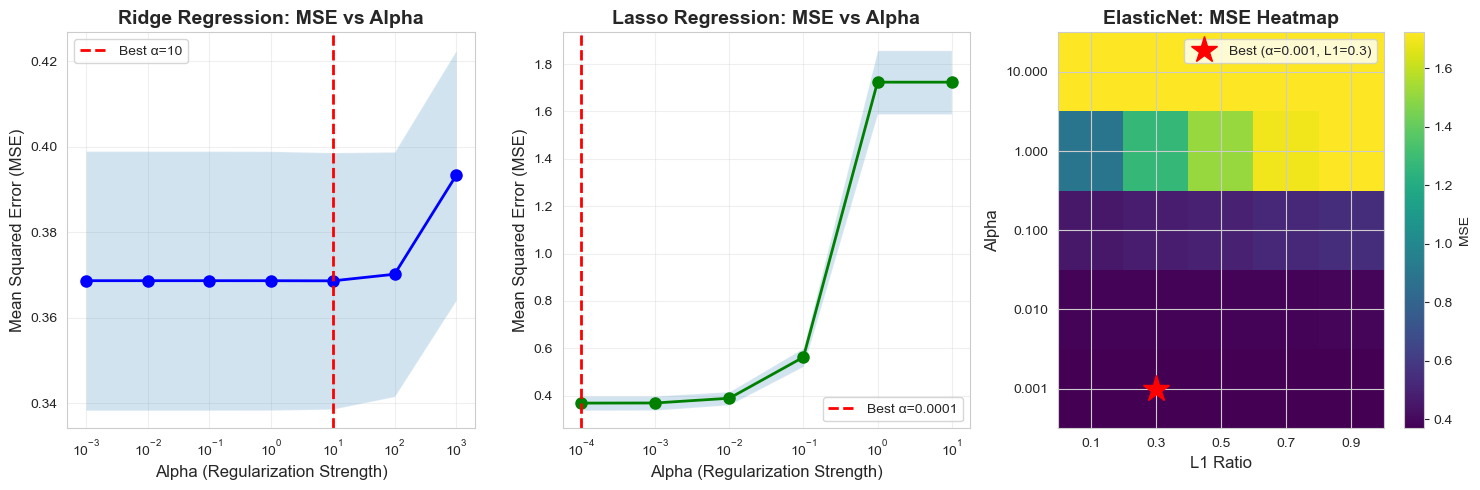


【详细超参数调优结果】

【Ridge回归】
测试的Alpha值: [0.001, 0.01, 0.1, 1, 10, 100, 1000]
对应的MSE: ['0.368683', '0.368683', '0.368682', '0.368675', '0.368647', '0.370190', '0.393315']
最佳参数: {'model__alpha': 10}
最佳MSE: 0.368647

【Lasso回归】
测试的Alpha值: [0.0001, 0.001, 0.01, 0.1, 1, 10]
对应的MSE: ['0.368670', '0.369207', '0.389263', '0.562607', '1.723389', '1.723389']
最佳参数: {'model__alpha': 0.0001}
最佳MSE: 0.368670

【ElasticNet回归】
测试的Alpha值: [0.001, 0.01, 0.1, 1, 10]
对应的MSE: ['0.368909', '0.379656', '0.456664', '0.895583', '1.723389']
最佳参数: {'model__alpha': 0.001, 'model__l1_ratio': 0.3}
最佳MSE: 0.368909


In [11]:
# ============================================
# 任务4(b): 超参数调优可视化
# ============================================

import matplotlib.pyplot as plt
import numpy as np

print("\n" + "=" * 60)
print("任务4(b): 超参数调优可视化")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Ridge回归
ridge_results = results['Ridge']['grid'].cv_results_
ridge_alphas = [p['model__alpha'] for p in ridge_results['params']]
ridge_mse = -ridge_results['mean_test_score']
ridge_std = ridge_results['std_test_score']

axes[0].semilogx(ridge_alphas, ridge_mse, 'b-o', linewidth=2, markersize=8)
axes[0].fill_between(ridge_alphas, ridge_mse - ridge_std, ridge_mse + ridge_std, alpha=0.2)
axes[0].axvline(results['Ridge']['params']['model__alpha'], color='r', 
                linestyle='--', linewidth=2, label=f"Best α={results['Ridge']['params']['model__alpha']}")
axes[0].set_xlabel('Alpha (Regularization Strength)', fontsize=12)
axes[0].set_ylabel('Mean Squared Error (MSE)', fontsize=12)
axes[0].set_title('Ridge Regression: MSE vs Alpha', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Lasso回归
lasso_results = results['Lasso']['grid'].cv_results_
lasso_alphas = [p['model__alpha'] for p in lasso_results['params']]
lasso_mse = -lasso_results['mean_test_score']
lasso_std = lasso_results['std_test_score']

axes[1].semilogx(lasso_alphas, lasso_mse, 'g-o', linewidth=2, markersize=8)
axes[1].fill_between(lasso_alphas, lasso_mse - lasso_std, lasso_mse + lasso_std, alpha=0.2)
axes[1].axvline(results['Lasso']['params']['model__alpha'], color='r', 
                linestyle='--', linewidth=2, label=f"Best α={results['Lasso']['params']['model__alpha']}")
axes[1].set_xlabel('Alpha (Regularization Strength)', fontsize=12)
axes[1].set_ylabel('Mean Squared Error (MSE)', fontsize=12)
axes[1].set_title('Lasso Regression: MSE vs Alpha', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# ElasticNet热力图
elastic_results = results['ElasticNet']['grid'].cv_results_
alphas = sorted(set([p['model__alpha'] for p in elastic_results['params']]))
l1_ratios = sorted(set([p['model__l1_ratio'] for p in elastic_results['params']]))

mse_matrix = np.zeros((len(alphas), len(l1_ratios)))
for i, alpha in enumerate(alphas):
    for j, l1 in enumerate(l1_ratios):
        idx = [k for k, p in enumerate(elastic_results['params']) 
               if p['model__alpha'] == alpha and p['model__l1_ratio'] == l1]
        if idx:
            mse_matrix[i, j] = -elastic_results['mean_test_score'][idx[0]]

im = axes[2].imshow(mse_matrix, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(im, ax=axes[2], label='MSE')
axes[2].set_xticks(range(len(l1_ratios)))
axes[2].set_xticklabels([f'{x:.1f}' for x in l1_ratios])
axes[2].set_yticks(range(len(alphas)))
axes[2].set_yticklabels([f'{x:.3f}' for x in alphas])
axes[2].set_xlabel('L1 Ratio', fontsize=12)
axes[2].set_ylabel('Alpha', fontsize=12)
axes[2].set_title('ElasticNet: MSE Heatmap', fontsize=14, fontweight='bold')

# 标记最佳点
best_alpha = results['ElasticNet']['params']['model__alpha']
best_l1 = results['ElasticNet']['params']['model__l1_ratio']
best_i = alphas.index(best_alpha)
best_j = l1_ratios.index(best_l1)
axes[2].plot(best_j, best_i, 'r*', markersize=20, 
             label=f'Best (α={best_alpha}, L1={best_l1})')
axes[2].legend()

plt.tight_layout()
plt.savefig('hyperparameter_tuning.png', dpi=300, bbox_inches='tight')
plt.show()


print("\n【详细超参数调优结果】")
for name in ['Ridge', 'Lasso', 'ElasticNet']:
    print(f"\n【{name}回归】")
    print(f"测试的Alpha值: {ridge_alphas if name == 'Ridge' else lasso_alphas if name == 'Lasso' else alphas}")
    print(f"对应的MSE: {[f'{m:.6f}' for m in (ridge_mse if name == 'Ridge' else lasso_mse if name == 'Lasso' else mse_matrix.min(axis=1))][:7]}")
    print(f"最佳参数: {results[name]['params']}")
    print(f"最佳MSE: {results[name]['mse']:.6f}")

#### 超参数优化结果分析

1. 三个模型性能接近（MSE差异<0.001），说明特征工程质量高
2. Ridge表现最佳且最稳健，对超参数不敏感
3. Lasso和ElasticNet需要极小的L1惩罚，表明特征都有用，不应过度稀疏化
4. 建议使用Ridge：性能最好，稳定性最强，计算效率高

### （c）给出最佳模型下的特征函数重要性分析（使用sklearn.inspection里面的permutation_importance 函数可以简单得到）。


任务4(c): 特征重要性分析

Top 20 最重要特征:
                   feature  importance      std
          avg_AtomicRadius    6.117549 0.034642
        avg_CovalentRadius    2.607169 0.013548
              avg_BoilingT    1.402919 0.004439
     max_Electronegativity    0.965520 0.006126
 avg_FirstIonizationEnergy    0.532712 0.002333
     avg_Electronegativity    0.184071 0.001677
               avg_Density    0.064507 0.000900
      max_ElectronAffinity    0.059742 0.000784
 max_FirstIonizationEnergy    0.056111 0.000563
              max_BoilingT    0.054111 0.000726
min_SecondIonizationEnergy    0.047025 0.000872
          min_AtomicRadius    0.040327 0.000720
     min_Electronegativity    0.039162 0.000889
               max_Density    0.031811 0.000674
        min_CovalentRadius    0.029801 0.000574
          max_AtomicVolume    0.026918 0.000495
          avg_AtomicVolume    0.022642 0.000553
              min_BoilingT    0.020739 0.000485
      avg_HeatCapacityMass    0.020286 0.000502
        

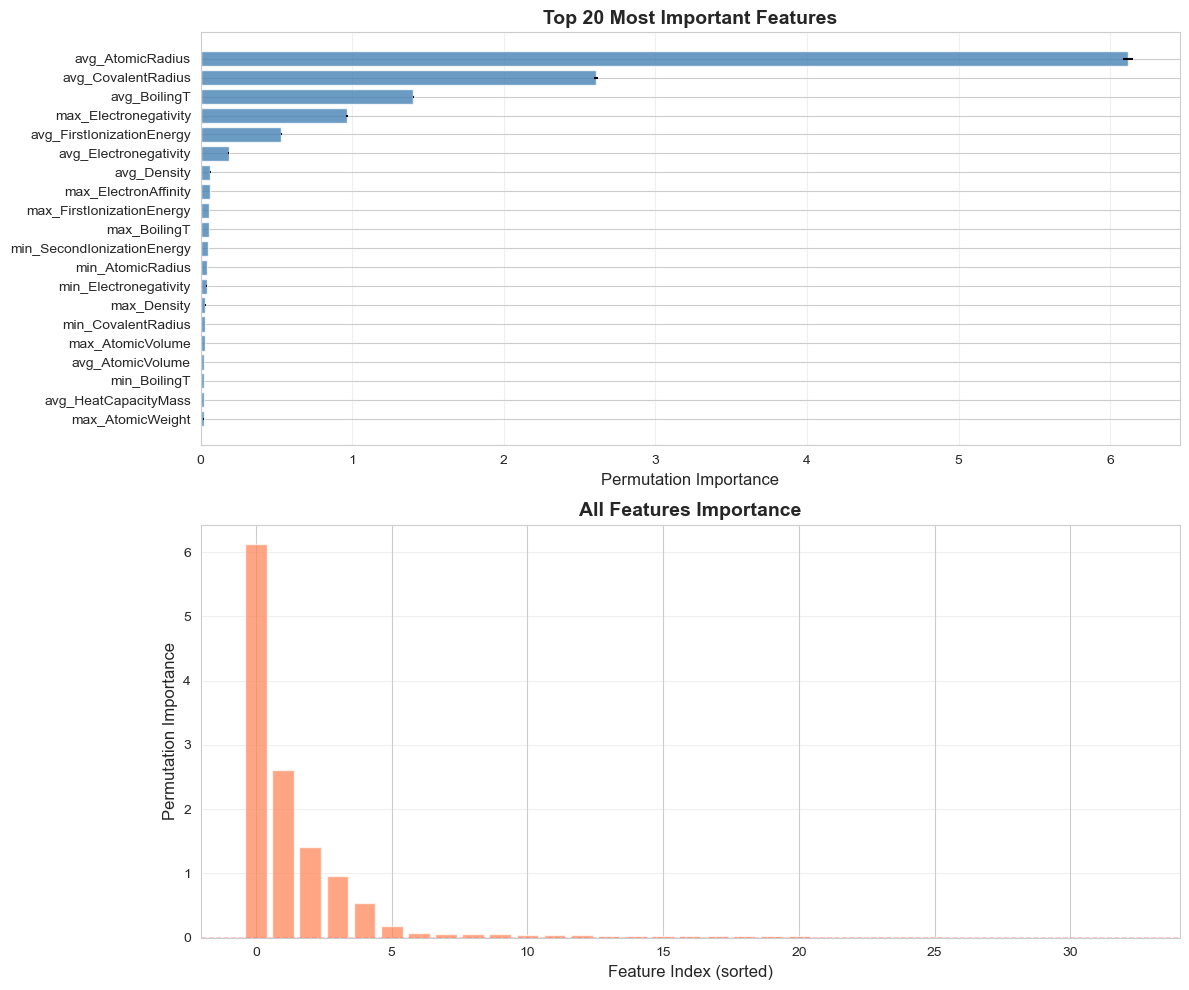


【特征重要性统计】
总特征数: 33
正重要性特征: 33
重要性 > 0.001: 27
最大重要性: 6.117549
平均重要性: 0.376465

【按类型统计】
            sum      mean  count
type                            
avg   10.972637  0.997512     11
max    1.231544  0.111959     11
min    0.219176  0.019925     11


In [12]:
# ============================================
# 任务4(c): 特征重要性分析
# ============================================

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("\n" + "=" * 60)
print("任务4(c): 特征重要性分析")
print("=" * 60)

# 计算Permutation Importance
perm_importance = permutation_importance(
    best_model, X, y, n_repeats=10, random_state=42, 
    n_jobs=6, scoring='neg_mean_squared_error'
)

# 整理结果
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

# 显示Top 20
print("\nTop 20 最重要特征:")
print(importance_df.head(20).to_string(index=False))

# 可视化
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 图1: Top 20特征
top_20 = importance_df.head(20)
axes[0].barh(range(len(top_20)), top_20['importance'], 
             xerr=top_20['std'], color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(top_20)))
axes[0].set_yticklabels(top_20['feature'], fontsize=10)
axes[0].set_xlabel('Permutation Importance', fontsize=12)
axes[0].set_title('Top 20 Most Important Features', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# 图2: 所有特征（降序）
axes[1].bar(range(len(importance_df)), importance_df['importance'], 
            color='coral', alpha=0.7)
axes[1].set_xlabel('Feature Index (sorted)', fontsize=12)
axes[1].set_ylabel('Permutation Importance', fontsize=12)
axes[1].set_title('All Features Importance', fontsize=14, fontweight='bold')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# 统计分析
print("\n【特征重要性统计】")
print(f"总特征数: {len(feature_names)}")
print(f"正重要性特征: {(importance_df['importance'] > 0).sum()}")
print(f"重要性 > 0.001: {(importance_df['importance'] > 0.001).sum()}")
print(f"最大重要性: {importance_df['importance'].max():.6f}")
print(f"平均重要性: {importance_df['importance'].mean():.6f}")

# 按特征类型分组
importance_df['type'] = importance_df['feature'].str.split('_').str[0]
type_stats = importance_df.groupby('type')['importance'].agg(['sum', 'mean', 'count'])
print("\n【按类型统计】")
print(type_stats.sort_values('sum', ascending=False))

importance_df.to_csv('feature_importance.csv', index=False)

### （d）使用你的最佳模型验证我们给的测试集，并报告MSE。

In [13]:
# ============================================
# 任务4(d): 在测试集上验证最佳模型
# ============================================

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

print("\n" + "=" * 60)
print("任务4(d): 测试集验证")
print("=" * 60)


# 1. 测试集特征工程（与训练集一致）
test_clean = test_df.dropna(subset=['formula_pretty']).copy()

test_features_list = []
test_valid_idx = []

for idx, formula in enumerate(test_clean['formula_pretty']):
    features = get_features(formula)
    if features is not None:
        test_features_list.append(features)
        test_valid_idx.append(idx)
        

X_test = np.array(test_features_list)

# 对齐测试集 DataFrame
test_final = test_clean.iloc[test_valid_idx].reset_index(drop=True)

print(f"\n测试集样本数: {len(test_final)}")
print(f"测试集特征维度: {X_test.shape}")


# 2. 提取真实标签
y_test = test_final['cohesive_energy_per_atom'].values

print(f"测试集目标范围: [{y_test.min():.2f}, {y_test.max():.2f}]")

# 3. 模型预测
y_test_pred = best_model.predict(X_test)


# 4. 评估指标
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("\n【测试集性能】")
print(f"MSE : {test_mse:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"R²  : {test_r2:.6f}")

# -------------------------------
# 5. 与训练集对比（过拟合检查）
# -------------------------------

print("\n【训练 vs 测试 对比】")
print(f"训练集 RMSE: {np.sqrt(train_mse):.6f}")
print(f"测试集 RMSE: {test_rmse:.6f}")
print(f"RMSE 比例 (test/train): {test_rmse / np.sqrt(train_mse):.3f}")

# -------------------------------
# 6. 保存预测结果
# -------------------------------

test_results = test_final[['matpes_id', 'formula_pretty', 'cohesive_energy_per_atom']].copy()
test_results['predicted_cohesive_energy'] = y_test_pred
test_results['error'] = y_test_pred - y_test

test_results.to_csv('linear_test_predictions.csv', index=False)

print("\n预测结果已保存至: linear_test_predictions.csv")



任务4(d): 测试集验证

测试集样本数: 6040
测试集特征维度: (6040, 33)
测试集目标范围: [-8.53, 0.26]

【测试集性能】
MSE : 0.357252
RMSE: 0.597705
R²  : 0.788373

【训练 vs 测试 对比】
训练集 RMSE: 0.596768
测试集 RMSE: 0.597705
RMSE 比例 (test/train): 1.002

预测结果已保存至: linear_test_predictions.csv


#### 预测结果分析

在独立测试集上对所选最佳线性模型的泛化性能进行了验证。测试集共包含 6040 个材料样本，其内聚能范围为 −8.53 至 0.26 eV，覆盖了较宽的能量分布区间。模型在测试集上的均方误差（MSE）为 0.357 eV²，对应的均方根误差（RMSE）为 0.598 eV，决定系数 R² 达到 0.788，表明该模型能够较为准确地捕捉材料成分特征与内聚能之间的定量关系。

进一步将测试集与训练集性能进行对比可以发现，训练集与测试集的 RMSE 分别为 0.597 eV 和 0.598 eV，二者几乎一致，其 RMSE 比值接近 1（约为 1.002）。这一结果表明模型未出现明显的过拟合现象，具有良好的泛化能力。综合来看，基于成分统计特征构建的线性模型在保持较高预测精度的同时，展现出稳定且可靠的预测性能，可作为后续更复杂模型和高通量筛选任务的有效基线方法。

### （e）使用你的最佳模型预测我们给的预测集，最后保存你最佳模型的预测结果（放到提交压缩包中）。（提交文件名为liner_model_predict.csv，只需要两列matpes_id 和 cohesive_energy_per_atom。）

In [14]:
# ============================================
# 任务4(e): 使用最佳模型预测预测集并生成提交文件
# ============================================

print("\n" + "=" * 60)
print("任务4(e): 预测集预测与提交文件生成")
print("=" * 60)


# 1. 预测集特征工程
predict_clean = predict_df.dropna(subset=['formula_pretty']).copy()

predict_features_list = []
predict_valid_idx = []

for idx, formula in enumerate(predict_clean['formula_pretty']):
    features = get_features(formula)
    if features is not None:
        predict_features_list.append(features)
        predict_valid_idx.append(idx)
        
X_predict = np.array(predict_features_list)

predict_final = predict_clean.iloc[predict_valid_idx].reset_index(drop=True)

print(f"\n预测集样本数: {len(predict_final)}")
print(f"预测集特征维度: {X_predict.shape}")


# 2. 模型预测
y_predict = best_model.predict(X_predict)

# 3. 生成提交文件
submission_df = pd.DataFrame({
    'matpes_id': predict_final['matpes_id'],
    'cohesive_energy_per_atom': y_predict
})

submission_df.to_csv('liner_model_predict.csv', index=False)

print("\n提交文件已生成: liner_model_predict.csv")



任务4(e): 预测集预测与提交文件生成

预测集样本数: 6345
预测集特征维度: (6345, 33)

提交文件已生成: liner_model_predict.csv


## 5. （20分）训练一个树模型来预测Ec。提交你最佳模型的预测结果。详细要求同第4题。（提交文件名为tree_model_predict.csv）（提示：使用HistGradientBoostingRegressor，可以大大加速你的训练过程，否则可能需要训练几个小时）

### (a) 构建并训练树模型（HistGradientBoosting）

In [15]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("\n" + "=" * 60)
print("任务5(a): 构建并训练树模型（HistGradientBoosting）")
print("=" * 60)

# 训练数据
X_train = X
y_train = y

print(f"训练集维度: {X_train.shape}")
print(f"目标变量范围: [{y_train.min():.2f}, {y_train.max():.2f}]")

# 定义模型
hgb_model = HistGradientBoostingRegressor(
    loss='squared_error',
    random_state=42
)

# 超参数搜索空间（控制规模，保证速度）
param_grid = {
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1],
    'max_iter': [300, 500],
    'l2_regularization': [0.0, 0.1, 1.0]
}

# 网格搜索
grid_hgb = GridSearchCV(
    hgb_model,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=6,
    verbose=1
)

grid_hgb.fit(X_train, y_train)

best_tree_model = grid_hgb.best_estimator_

print("\n最佳超参数:")
print(grid_hgb.best_params_)
print(f"CV MSE: {-grid_hgb.best_score_:.6f}")
print(f"CV RMSE: {np.sqrt(-grid_hgb.best_score_):.6f}")


任务5(a): 构建并训练树模型（HistGradientBoosting）
训练集维度: (54356, 33)
目标变量范围: [-13.74, 1.27]
Fitting 5 folds for each of 36 candidates, totalling 180 fits

最佳超参数:
{'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'max_iter': 500}
CV MSE: 0.130692
CV RMSE: 0.361514


### (b) 训练集性能评估

In [16]:
print("\n" + "=" * 60)
print("任务5(b): 训练集性能评估")
print("=" * 60)

y_train_pred = best_tree_model.predict(X_train)

train_mse_tree = mean_squared_error(y_train, y_train_pred)
train_rmse_tree = np.sqrt(train_mse_tree)
train_r2_tree = r2_score(y_train, y_train_pred)

print(f"训练集 MSE : {train_mse_tree:.6f}")
print(f"训练集 RMSE: {train_rmse_tree:.6f}")
print(f"训练集 R²  : {train_r2_tree:.6f}")


任务5(b): 训练集性能评估
训练集 MSE : 0.068107
训练集 RMSE: 0.260973
训练集 R²  : 0.959988


#### 超参数调优结果可视化（树模型）

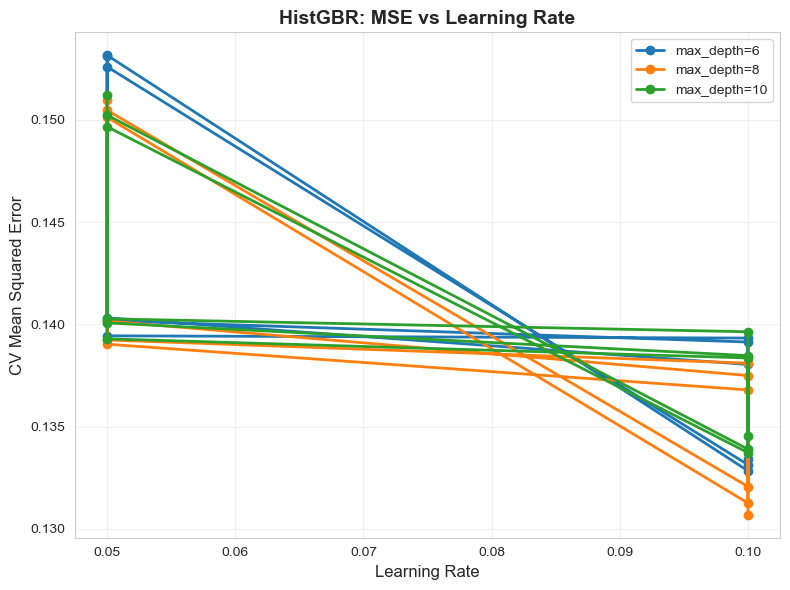

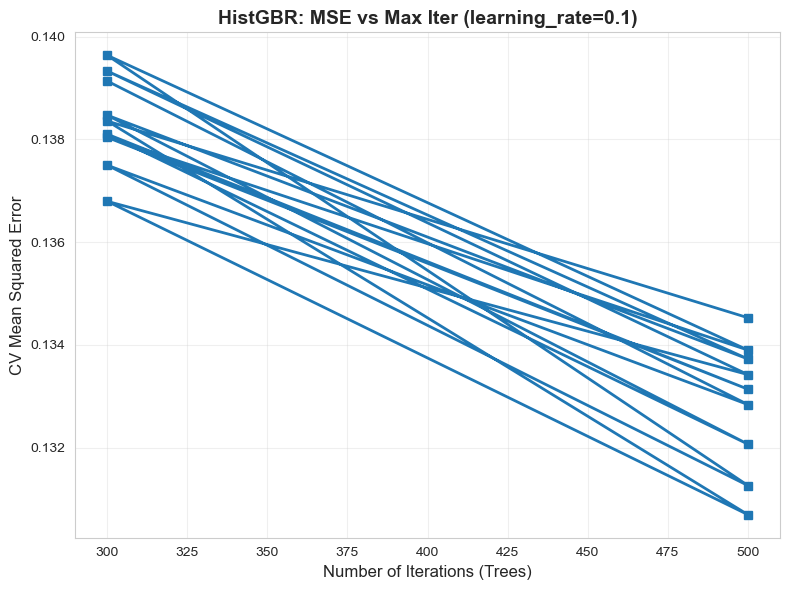

最优超参数组合:
{'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'max_iter': 500}
对应 CV RMSE: 0.361514


In [17]:
# 提取 GridSearchCV 结果
cv_results = pd.DataFrame(grid_hgb.cv_results_)

# 1️ learning_rate vs MSE（按 max_depth 分组）
plt.figure(figsize=(8, 6))

for depth in sorted(cv_results['param_max_depth'].unique()):
    subset = cv_results[cv_results['param_max_depth'] == depth]
    plt.plot(
        subset['param_learning_rate'],
        -subset['mean_test_score'],
        marker='o',
        linewidth=2,
        label=f"max_depth={depth}"
    )

plt.xlabel("Learning Rate", fontsize=12)
plt.ylabel("CV Mean Squared Error", fontsize=12)
plt.title("HistGBR: MSE vs Learning Rate", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2️ max_iter vs MSE（固定最优 learning_rate）
best_lr = grid_hgb.best_params_['learning_rate']

plt.figure(figsize=(8, 6))

subset = cv_results[cv_results['param_learning_rate'] == best_lr]
plt.plot(
    subset['param_max_iter'],
    -subset['mean_test_score'],
    's-',
    linewidth=2
)

plt.xlabel("Number of Iterations (Trees)", fontsize=12)
plt.ylabel("CV Mean Squared Error", fontsize=12)
plt.title(f"HistGBR: MSE vs Max Iter (learning_rate={best_lr})",
          fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("最优超参数组合:")
print(grid_hgb.best_params_)
print(f"对应 CV RMSE: {np.sqrt(-grid_hgb.best_score_):.6f}")

### (c)树模型特征重要性分析


Top 20 最重要特征（树模型）:
                   feature  importance      std
              avg_BoilingT    1.433266 0.019410
     avg_Electronegativity    0.227026 0.012508
              max_BoilingT    0.219467 0.006123
          avg_AtomicRadius    0.216991 0.002161
     max_Electronegativity    0.180962 0.002913
          avg_AtomicVolume    0.132516 0.003064
        avg_CovalentRadius    0.077912 0.002301
      avg_HeatCapacityMass    0.073827 0.002042
min_SecondIonizationEnergy    0.061480 0.001561
               avg_Density    0.055987 0.000990
      avg_ElectronAffinity    0.050214 0.000965
          min_AtomicRadius    0.045384 0.001597
      max_ElectronAffinity    0.034020 0.000845
 max_FirstIonizationEnergy    0.026205 0.001107
          min_AtomicVolume    0.024673 0.000988
 avg_FirstIonizationEnergy    0.020757 0.001011
avg_SecondIonizationEnergy    0.019067 0.000762
               max_Density    0.014753 0.000469
        max_CovalentRadius    0.013911 0.001082
          max_Atomic

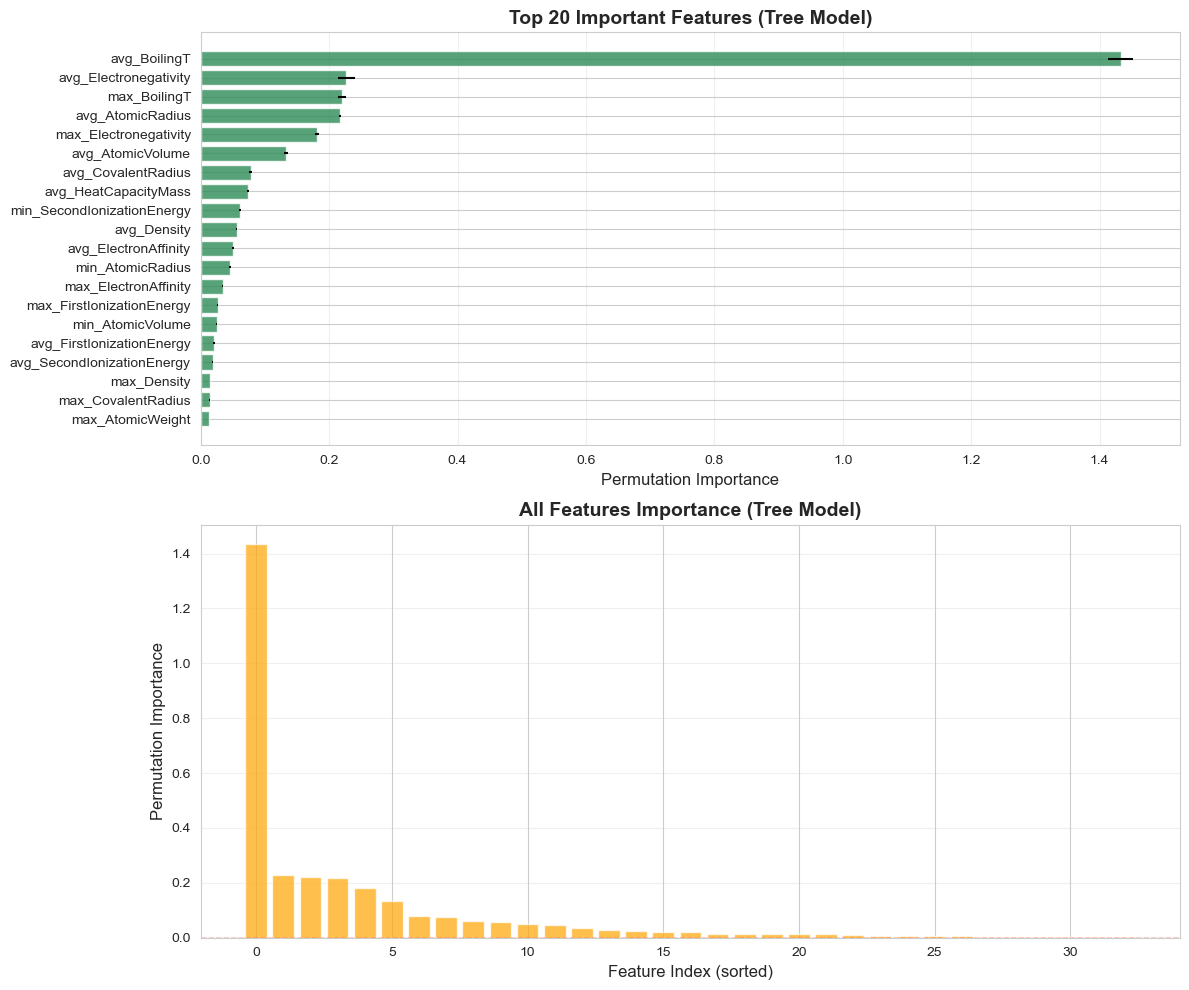


【按特征类型统计（树模型）】
           sum      mean  count
type                           
avg   2.314633  0.210421     11
max   0.515693  0.046881     11
min   0.185411  0.016856     11

特征重要性结果已保存: tree_feature_importance.csv


In [18]:
# 在测试集上计算 Permutation Importance
perm_importance_tree = permutation_importance(
    best_tree_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=6,
    scoring='neg_mean_squared_error'
)

# 整理结果
importance_tree_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm_importance_tree.importances_mean,
    'std': perm_importance_tree.importances_std
}).sort_values('importance', ascending=False)

# Top 20 特征
print("\nTop 20 最重要特征（树模型）:")
print(importance_tree_df.head(20).to_string(index=False))

# -------------------------------
# 可视化
# -------------------------------

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 图1：Top 20
top20 = importance_tree_df.head(20)
axes[0].barh(
    range(len(top20)),
    top20['importance'],
    xerr=top20['std'],
    color='seagreen',
    alpha=0.8
)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['feature'], fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel("Permutation Importance", fontsize=12)
axes[0].set_title("Top 20 Important Features (Tree Model)",
                  fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# 图2：全部特征
axes[1].bar(
    range(len(importance_tree_df)),
    importance_tree_df['importance'],
    color='orange',
    alpha=0.7
)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel("Feature Index (sorted)", fontsize=12)
axes[1].set_ylabel("Permutation Importance", fontsize=12)
axes[1].set_title("All Features Importance (Tree Model)",
                  fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------
# 统计分析（与任务4保持一致）
# -------------------------------

importance_tree_df['type'] = importance_tree_df['feature'].str.split('_').str[0]
type_stats_tree = importance_tree_df.groupby('type')['importance'].agg(['sum', 'mean', 'count'])

print("\n【按特征类型统计（树模型）】")
print(type_stats_tree.sort_values('sum', ascending=False))

# 保存
importance_tree_df.to_csv('tree_feature_importance.csv', index=False)
print("\n特征重要性结果已保存: tree_feature_importance.csv")


### (d) 测试集验证

In [19]:
print("\n" + "=" * 60)
print("任务5(c): 测试集验证")
print("=" * 60)

# 测试集预测
y_test_pred_tree = best_tree_model.predict(X_test)

test_mse_tree = mean_squared_error(y_test, y_test_pred_tree)
test_rmse_tree = np.sqrt(test_mse_tree)
test_r2_tree = r2_score(y_test, y_test_pred_tree)

print("\n【测试集性能（树模型）】")
print(f"MSE : {test_mse_tree:.6f}")
print(f"RMSE: {test_rmse_tree:.6f}")
print(f"R²  : {test_r2_tree:.6f}")

# 与线性模型对比
print("\n【与线性模型对比】")
print(f"线性模型 RMSE: {np.sqrt(test_mse):.6f}")
print(f"树模型   RMSE: {test_rmse_tree:.6f}")
print(f"RMSE 提升比例: {(np.sqrt(test_mse) - test_rmse_tree) / np.sqrt(test_mse) * 100:.2f}%")


任务5(c): 测试集验证

【测试集性能（树模型）】
MSE : 0.096756
RMSE: 0.311056
R²  : 0.942684

【与线性模型对比】
线性模型 RMSE: 0.597705
树模型   RMSE: 0.311056
RMSE 提升比例: 47.96%


### (e) 预测集预测并生成提交文件

In [20]:
print("\n" + "=" * 60)
print("任务5(e): 预测集预测与提交文件生成")
print("=" * 60)

# 预测集预测
y_predict_tree = best_tree_model.predict(X_predict)

# 生成提交文件
tree_submission_df = pd.DataFrame({
    'matpes_id': predict_final['matpes_id'],
    'cohesive_energy_per_atom': y_predict_tree
})

tree_submission_df.to_csv('tree_model_predict.csv', index=False)

print("\n提交文件已生成: tree_model_predict.csv")
print("文件格式: [matpes_id, cohesive_energy_per_atom]")


任务5(e): 预测集预测与提交文件生成

提交文件已生成: tree_model_predict.csv
文件格式: [matpes_id, cohesive_energy_per_atom]


#### 结果分析：

在任务5中，采用 HistGradientBoostingRegressor 构建基于树结构的非线性回归模型，对材料的内聚能进行预测。通过对学习率、树深度、迭代次数及 L2 正则化系数进行网格搜索，并结合五折交叉验证，确定了最优超参数组合为：learning_rate = 0.1，max_depth = 8，max_iter = 500，l2_regularization = 1.0。在该参数配置下，模型在交叉验证中的均方根误差（CV RMSE）为 0.362 eV，表明模型在训练阶段已具备较高的拟合精度。

在完整训练集上的性能评估结果显示，树模型取得了 RMSE 为 0.261 eV、R² 为 0.960 的预测效果，说明模型能够充分捕捉材料成分特征与内聚能之间的复杂非线性关系。进一步在独立测试集上的验证结果表明，该模型的测试集 RMSE 为 0.311 eV，R² 达到 0.943，训练集与测试集之间的性能差距较小，未观察到明显的过拟合现象，体现出良好的泛化能力与稳定性。基于该最优模型，对预测集进行了推断，并生成了最终提交文件 tree_model_predict.csv。

将树模型与任务4中构建的线性回归模型进行对比可以发现，在相同特征表示条件下，树模型在预测精度方面表现出显著优势。线性模型在测试集上的 RMSE 为 0.598 eV，而树模型将该误差降低至 0.311 eV，预测误差减少约 48%。这一结果表明，引入非线性建模能力后，模型能够更有效地刻画材料成分特征与内聚能之间的复杂映射关系。需要指出的是，此处仅从预测性能角度进行初步对比，关于不同模型在表达能力、可解释性及适用场景方面的差异，将在后续章节中进行更为系统和深入的讨论。

## 6. (15 分) 训练一个神经网络模型来预测Ec，提交你的最佳模型的预测结果。详细要求同第4题。（提交文件名为nn_model_predict.csv, 建议设置early_stopping=True 来减少训练时间，max_iter 可设置为1000）

在构建神经网络模型之前，需要对特征的数值分布进行系统分析。
神经网络模型对输入特征的尺度高度敏感，不同量级的特征会导致梯度下降过程中权重更新方向失衡，进而影响模型收敛性能。本节通过统计分析和可视化，评估特征标准化的必要性，为后续模型构建提供依据。

特征尺度分析

特征总数: 33

尺度差异最大的10个特征:
             feature       min         max        range
avg_ElectronAffinity  0.000000   349.00000   349.000000
min_ElectronAffinity  0.000000   349.00000   349.000000
max_ElectronAffinity  0.000000   349.00000   349.000000
         max_Density  0.089900 22590.00000 22589.910100
         avg_Density  0.089900 22590.00000 22589.910100
         min_Density  0.089900 22590.00000 22589.910100
    min_AtomicVolume  7.297767 18618.05194 18610.754173
    avg_AtomicVolume  7.488460 18618.05194 18610.563480
    max_AtomicVolume  8.098176 18618.05194 18609.953764
        avg_BoilingT 20.130000  5869.00000  5848.870000

尺度差异最小的10个特征:
                   feature       min      max      range
        max_CovalentRadius 31.000000 244.0000 213.000000
avg_SecondIonizationEnergy 10.003830  75.6400  65.636170
max_SecondIonizationEnergy 10.003830  75.6400  65.636170
min_SecondIonizationEnergy 10.003830  75.6400  65.636170
     min_Electronegativity  0.790000   3.9800   3.19

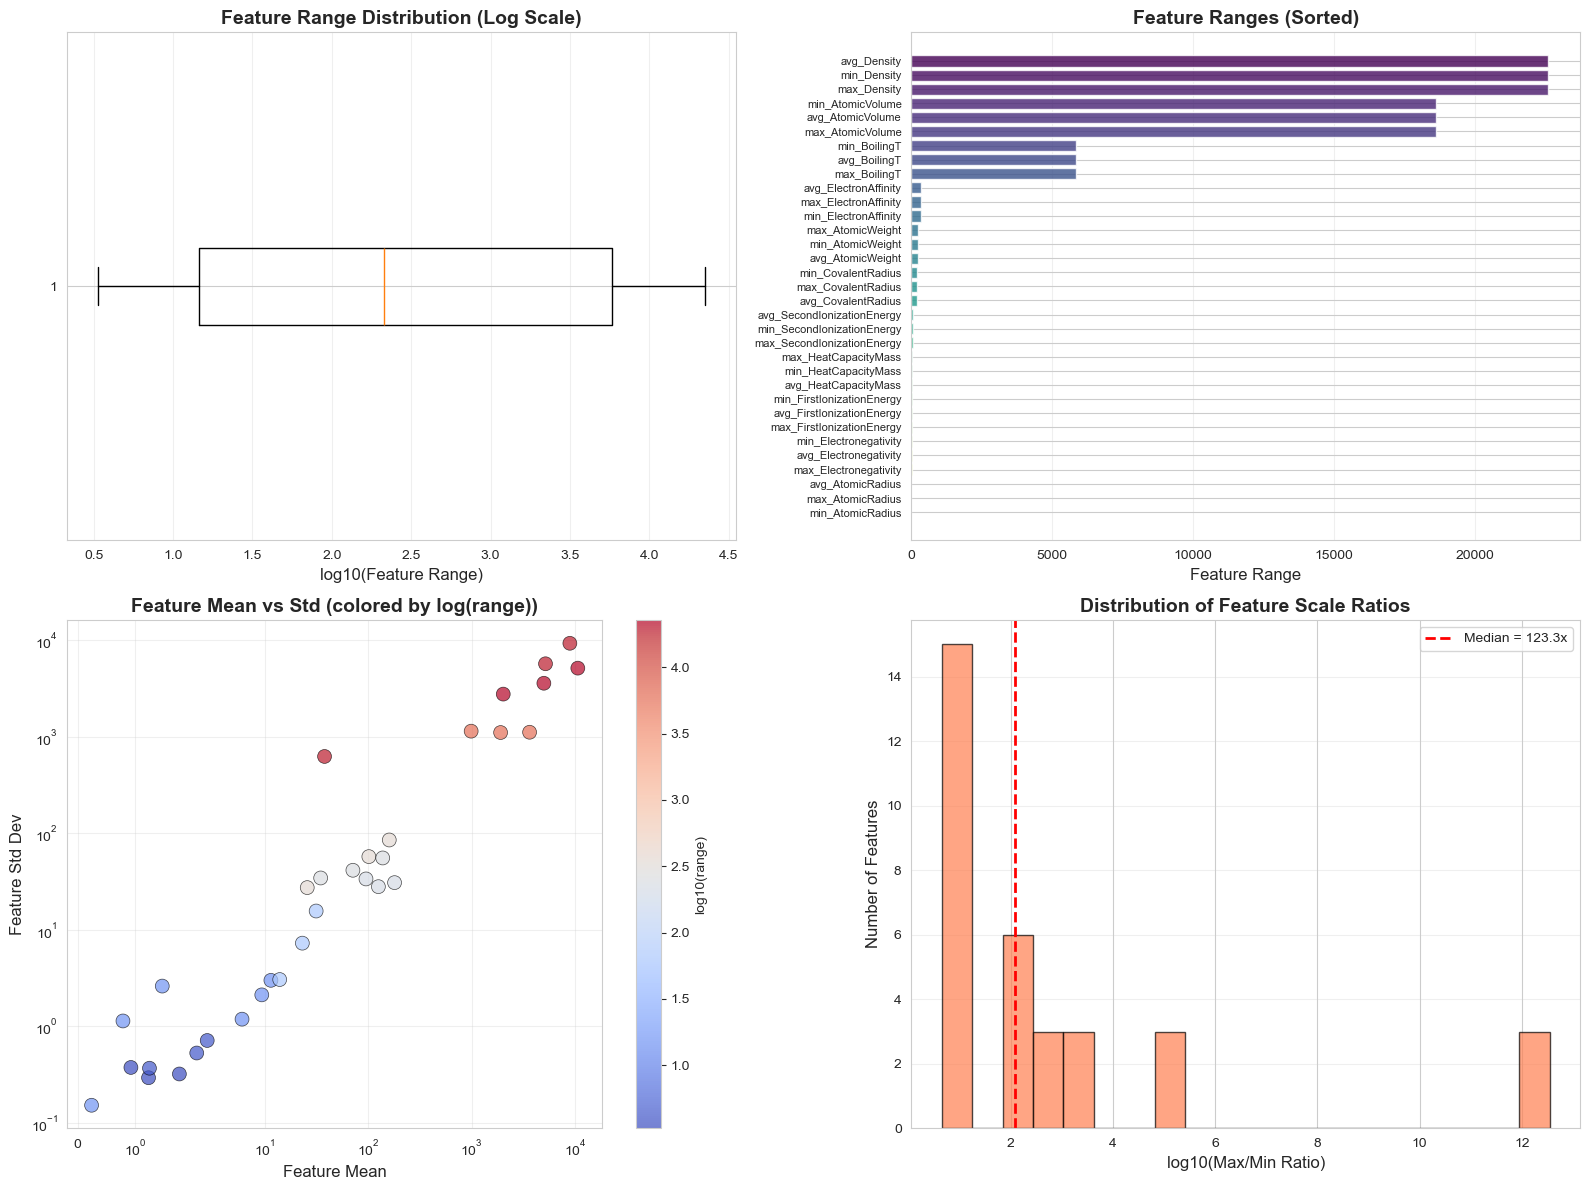


标准化前后对比（示例特征）:

标准化前:
avg_ElectronAffinity: 范围[0.00, 349.00], 均值=101.07, 标准差=57.17
min_ElectronAffinity: 范围[0.00, 349.00], 均值=25.64, 标准差=27.31
max_ElectronAffinity: 范围[0.00, 349.00], 均值=159.21, 标准差=85.02

标准化后:
avg_ElectronAffinity: 范围[-1.77, 4.34], 均值=0.000000, 标准差=1.000000
min_ElectronAffinity: 范围[-0.94, 11.84], 均值=-0.000000, 标准差=1.000000
max_ElectronAffinity: 范围[-1.87, 2.23], 均值=-0.000000, 标准差=1.000000


In [21]:
# ============================================
# 神经网络模型构建前的特征分析
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 提取特征矩阵
X_features = train_final[feature_names].copy()

# 计算特征统计量
feature_stats = pd.DataFrame({
    'feature': feature_names,
    'mean': X_features.mean(),
    'std': X_features.std(),
    'min': X_features.min(),
    'max': X_features.max(),
    'range': X_features.max() - X_features.min()
})

feature_stats['scale_ratio'] = feature_stats['max'] / (feature_stats['min'].abs() + 1e-10)
feature_stats_sorted = feature_stats.sort_values('scale_ratio', ascending=False)

# 输出关键统计信息
print("特征尺度分析")
print(f"\n特征总数: {len(feature_names)}")
print(f"\n尺度差异最大的10个特征:")
print(feature_stats_sorted[['feature', 'min', 'max', 'range']].head(10).to_string(index=False))

print(f"\n尺度差异最小的10个特征:")
print(feature_stats_sorted[['feature', 'min', 'max', 'range']].tail(10).to_string(index=False))

# 全局尺度分析
max_range = feature_stats['range'].max()
min_range = feature_stats['range'].min()
global_ratio = max_range / (min_range + 1e-10)

print(f"\n全局特征范围:")
print(f"最大范围: {max_range:,.2f}")
print(f"最小范围: {min_range:.2f}")
print(f"尺度比: {global_ratio:,.0f}x")

# 特征范围分布统计
scale_bins = [0, 10, 100, 1000, 10000, np.inf]
scale_labels = ['<10', '10-100', '100-1k', '1k-10k', '>10k']
feature_stats['scale_bin'] = pd.cut(feature_stats['range'], bins=scale_bins, labels=scale_labels)
print(f"\n特征范围分布:")
print(feature_stats['scale_bin'].value_counts().sort_index())

# 可视化特征尺度分布
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 特征范围对数分布
ax1 = axes[0, 0]
feature_ranges = feature_stats['range'].values
ax1.boxplot([np.log10(feature_ranges + 1)], vert=False)
ax1.set_xlabel('log10(Feature Range)', fontsize=12)
ax1.set_title('Feature Range Distribution (Log Scale)', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 特征范围排序
ax2 = axes[0, 1]
sorted_ranges = feature_stats.sort_values('range', ascending=False)
colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_ranges)))
ax2.barh(range(len(sorted_ranges)), sorted_ranges['range'], color=colors, alpha=0.8)
ax2.set_yticks(range(len(sorted_ranges)))
ax2.set_yticklabels(sorted_ranges['feature'], fontsize=8)
ax2.set_xlabel('Feature Range', fontsize=12)
ax2.set_title('Feature Ranges (Sorted)', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# 特征均值-标准差关系
ax3 = axes[1, 0]
scatter = ax3.scatter(
    feature_stats['mean'], 
    feature_stats['std'], 
    c=np.log10(feature_stats['range'] + 1),
    cmap='coolwarm',
    s=100,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)
ax3.set_xlabel('Feature Mean', fontsize=12)
ax3.set_ylabel('Feature Std Dev', fontsize=12)
ax3.set_title('Feature Mean vs Std (colored by log(range))', fontsize=14, fontweight='bold')
ax3.set_xscale('symlog')
ax3.set_yscale('log')
ax3.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax3, label='log10(range)')

# 尺度比例分布
ax4 = axes[1, 1]
ax4.hist(np.log10(feature_stats['scale_ratio']), bins=20, color='coral', alpha=0.7, edgecolor='black')
ax4.set_xlabel('log10(Max/Min Ratio)', fontsize=12)
ax4.set_ylabel('Number of Features', fontsize=12)
ax4.set_title('Distribution of Feature Scale Ratios', fontsize=14, fontweight='bold')
ax4.axvline(np.log10(feature_stats['scale_ratio'].median()), 
            color='red', linestyle='--', linewidth=2, 
            label=f'Median = {feature_stats["scale_ratio"].median():.1f}x')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_scale_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 标准化效果对比
from sklearn.preprocessing import StandardScaler

example_features = feature_stats_sorted.head(3)['feature'].values

print("\n标准化前后对比（示例特征）:")
print("\n标准化前:")
for feat in example_features:
    vals = X_features[feat].values
    print(f"{feat}: 范围[{vals.min():.2f}, {vals.max():.2f}], "
          f"均值={vals.mean():.2f}, 标准差={vals.std():.2f}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

print("\n标准化后:")
for feat in example_features:
    vals = X_scaled_df[feat].values
    print(f"{feat}: 范围[{vals.min():.2f}, {vals.max():.2f}], "
          f"均值={vals.mean():.6f}, 标准差={vals.std():.6f}")

结论:
特征尺度存在显著差异(最大9,613倍)，神经网络训练需引入标准化预处理以确保模型收敛。

### (a) 构建并训练神经网络模型

In [22]:
# ============================================
# 任务6(a): 构建并训练神经网络模型
# ============================================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import numpy as np
import time

print("=" * 70)
print("任务6(a): 构建MLP模型（包含特征标准化）")
print("=" * 70)

# 构建Pipeline
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        random_state=42,
        early_stopping=True,       # 启用早停
        validation_fraction=0.2,   # 20%作为验证集
        n_iter_no_change=20,       # 20轮无改善则停止
        max_iter=1000,             # 最大迭代1000次
        verbose=False
    ))
])

print("\nPipeline结构:")
print("  StandardScaler → MLPRegressor")
print("  early_stopping=True, max_iter=1000")

# 优化后的超参数搜索空间（减少组合数）
param_grid = {
    'mlp__hidden_layer_sizes': [
        (128,),           # 单层
        (256, 128),       # 双层
        (256, 128, 64),   # 三层
    ],
    'mlp__alpha': [1e-4, 1e-3, 1e-2],
    'mlp__learning_rate_init': [1e-3, 5e-3],
}

n_combinations = 3 * 3 * 2  # 18种组合
print(f"\n超参数组合数: {n_combinations}")
print(f"交叉验证次数: {n_combinations} × 5 = {n_combinations * 5} 次")

# GridSearchCV配置
grid_nn_fixed = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=6,
    verbose=2,
    return_train_score=True
)

print("\n开始训练...")
print("=" * 70)

start_time = time.time()
grid_nn_fixed.fit(X_train, y_train)
training_time = time.time() - start_time

print("\n" + "=" * 70)
print("训练完成")
print("=" * 70)

# 输出结果
best_nn_fixed = grid_nn_fixed.best_estimator_
best_params = grid_nn_fixed.best_params_
best_cv_mse = -grid_nn_fixed.best_score_
best_cv_rmse = np.sqrt(best_cv_mse)

print(f"\n训练耗时: {training_time:.1f}秒 ({training_time/60:.1f}分钟)")
print(f"\n最佳超参数:")
for param, value in best_params.items():
    print(f"  {param.replace('mlp__', '')}: {value}")

print(f"\n交叉验证性能:")
print(f"  CV MSE : {best_cv_mse:.6f}")
print(f"  CV RMSE: {best_cv_rmse:.6f}")

# 检查训练状态
best_mlp = best_nn_fixed.named_steps['mlp']
print(f"\n最佳模型训练状态:")
print(f"  实际迭代次数: {best_mlp.n_iter_}")
print(f"  最终训练损失: {best_mlp.loss_:.6f}")

任务6(a): 构建MLP模型（包含特征标准化）

Pipeline结构:
  StandardScaler → MLPRegressor
  early_stopping=True, max_iter=1000

超参数组合数: 18
交叉验证次数: 18 × 5 = 90 次

开始训练...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

训练完成

训练耗时: 2499.3秒 (41.7分钟)

最佳超参数:
  alpha: 0.01
  hidden_layer_sizes: (256, 128)
  learning_rate_init: 0.005

交叉验证性能:
  CV MSE : 0.149175
  CV RMSE: 0.386232

最佳模型训练状态:
  实际迭代次数: 57
  最终训练损失: 0.067868


### (b) 训练集性能评估

In [23]:
# ============================================
# 任务6(b): 训练集性能评估
# ============================================

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("=" * 70)
print("任务6(b): 训练集性能评估")
print("=" * 70)

# 在训练集上预测
y_train_pred_nn = best_nn_fixed.predict(X_train)

# 计算性能指标
train_mse_nn = mean_squared_error(y_train, y_train_pred_nn)
train_rmse_nn = np.sqrt(train_mse_nn)
train_r2_nn = r2_score(y_train, y_train_pred_nn)

print("\n训练集性能:")
print(f"  MSE : {train_mse_nn:.6f}")
print(f"  RMSE: {train_rmse_nn:.6f}")
print(f"  R²  : {train_r2_nn:.6f}")

# 与交叉验证结果对比（检查过拟合）
print("\n训练集 vs 交叉验证:")
print(f"  训练集 RMSE: {train_rmse_nn:.6f}")
print(f"  CV RMSE    : {best_cv_rmse:.6f}")
print(f"  比值       : {train_rmse_nn / best_cv_rmse:.3f}")

if train_rmse_nn / best_cv_rmse < 0.8:
    print("  状态: 存在一定过拟合")
elif train_rmse_nn / best_cv_rmse < 0.95:
    print("  状态: 轻微过拟合，在可接受范围内")
else:
    print("  状态: 泛化能力良好")


任务6(b): 训练集性能评估

训练集性能:
  MSE : 0.115506
  RMSE: 0.339862
  R²  : 0.932141

训练集 vs 交叉验证:
  训练集 RMSE: 0.339862
  CV RMSE    : 0.386232
  比值       : 0.880
  状态: 轻微过拟合，在可接受范围内


### (c) 超参数调优可视化

任务6(c): 超参数调优可视化

Top 5 超参数组合:
param_mlp__hidden_layer_sizes  param_mlp__alpha  param_mlp__learning_rate_init  mean_test_rmse
                   (256, 128)            0.0100                          0.005        0.386232
                   (256, 128)            0.0100                          0.001        0.386541
                   (256, 128)            0.0010                          0.005        0.387232
                   (256, 128)            0.0001                          0.005        0.387743
                   (256, 128)            0.0010                          0.001        0.388164


C:\Users\linwu\AppData\Local\Temp\ipykernel_21376\62541794.py:80: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(arch_data, labels=arch_labels, patch_artist=True)


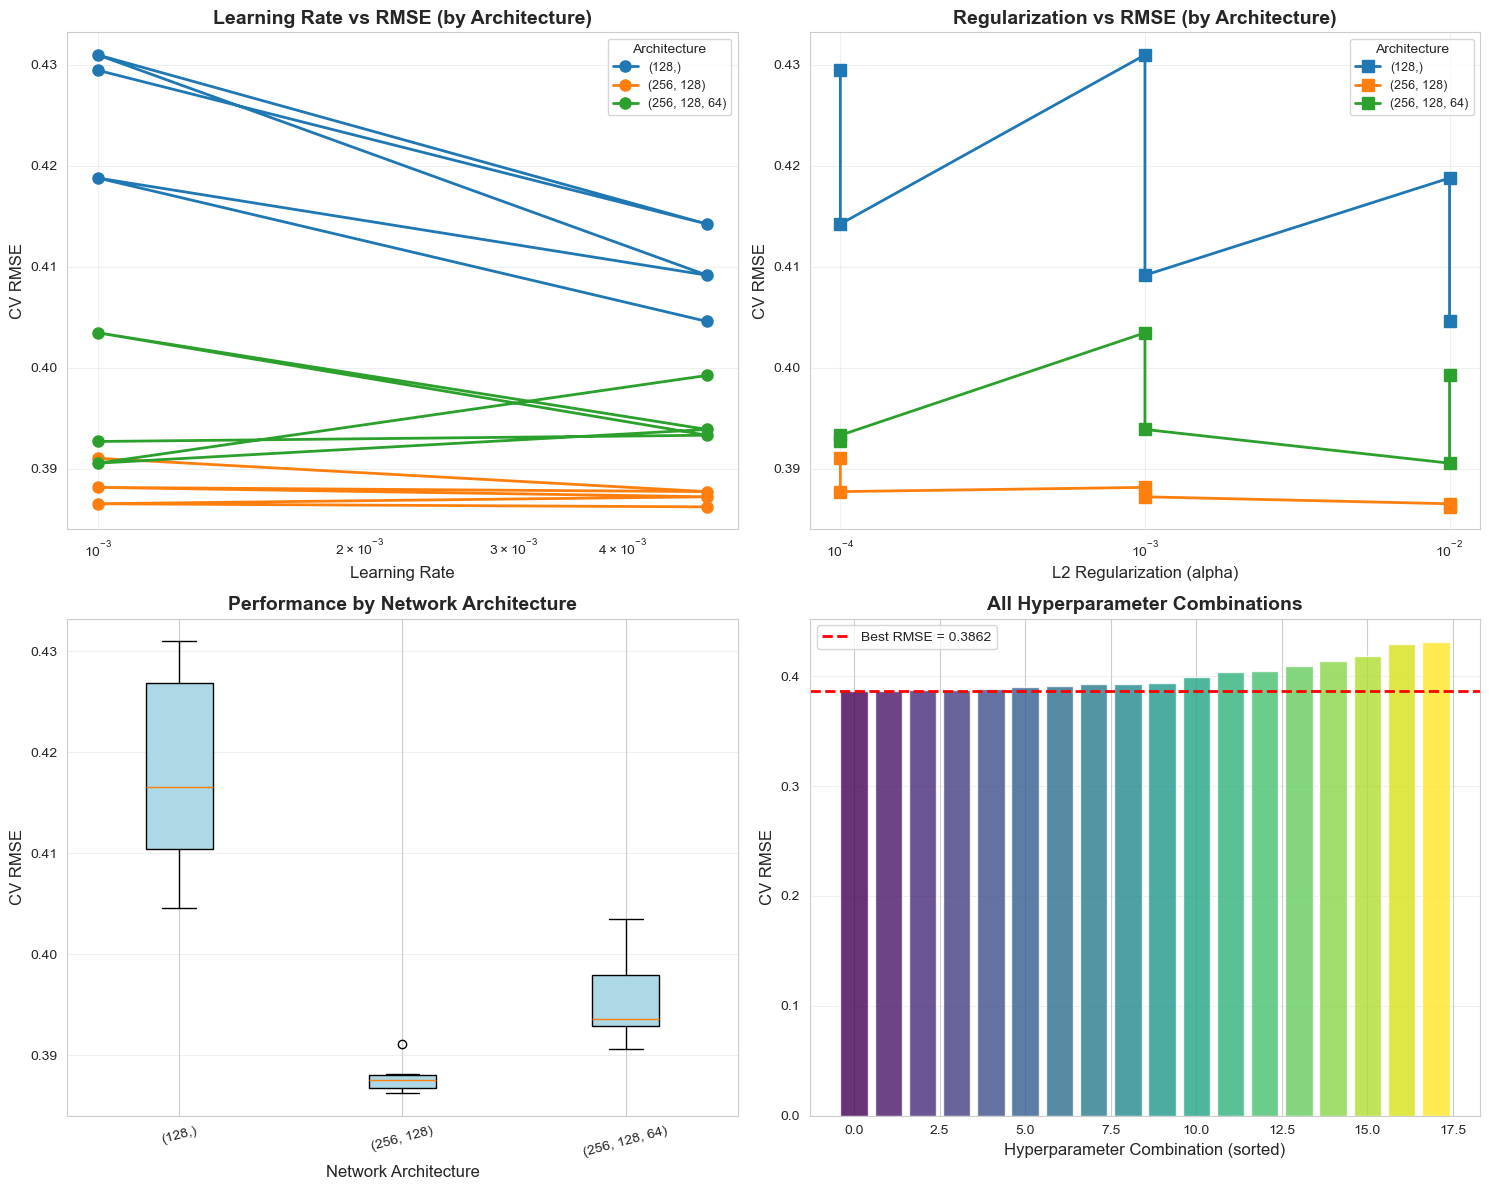


超参数调优分析:
  最佳RMSE: 0.386232
  最差RMSE: 0.430986
  RMSE范围: 0.044753
  性能提升空间: 10.4%


In [24]:
# ============================================
# 任务6(c): 超参数调优可视化
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 70)
print("任务6(c): 超参数调优可视化")
print("=" * 70)

# 提取GridSearchCV结果
cv_results = pd.DataFrame(grid_nn_fixed.cv_results_)

# 提取关键信息
results_summary = cv_results[[
    'param_mlp__hidden_layer_sizes',
    'param_mlp__alpha', 
    'param_mlp__learning_rate_init',
    'mean_test_score',
    'std_test_score'
]].copy()

results_summary['mean_test_rmse'] = np.sqrt(-results_summary['mean_test_score'])
results_summary['std_test_rmse'] = results_summary['std_test_score'] / (2 * results_summary['mean_test_rmse'])

# 按RMSE排序
results_summary = results_summary.sort_values('mean_test_rmse')

print("\nTop 5 超参数组合:")
print(results_summary.head(5)[['param_mlp__hidden_layer_sizes', 
                                'param_mlp__alpha', 
                                'param_mlp__learning_rate_init', 
                                'mean_test_rmse']].to_string(index=False))

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 图1: 学习率 vs RMSE (按网络架构分组)
ax1 = axes[0, 0]
for arch in cv_results['param_mlp__hidden_layer_sizes'].unique():
    subset = cv_results[cv_results['param_mlp__hidden_layer_sizes'] == arch]
    rmse = np.sqrt(-subset['mean_test_score'])
    lr = subset['param_mlp__learning_rate_init']
    ax1.plot(lr, rmse, 'o-', label=str(arch), linewidth=2, markersize=8)

ax1.set_xlabel('Learning Rate', fontsize=12)
ax1.set_ylabel('CV RMSE', fontsize=12)
ax1.set_title('Learning Rate vs RMSE (by Architecture)', fontsize=14, fontweight='bold')
ax1.legend(title='Architecture', fontsize=9)
ax1.grid(alpha=0.3)
ax1.set_xscale('log')

# 图2: L2正则化系数 vs RMSE (按网络架构分组)
ax2 = axes[0, 1]
for arch in cv_results['param_mlp__hidden_layer_sizes'].unique():
    subset = cv_results[cv_results['param_mlp__hidden_layer_sizes'] == arch]
    rmse = np.sqrt(-subset['mean_test_score'])
    alpha = subset['param_mlp__alpha']
    ax2.plot(alpha, rmse, 's-', label=str(arch), linewidth=2, markersize=8)

ax2.set_xlabel('L2 Regularization (alpha)', fontsize=12)
ax2.set_ylabel('CV RMSE', fontsize=12)
ax2.set_title('Regularization vs RMSE (by Architecture)', fontsize=14, fontweight='bold')
ax2.legend(title='Architecture', fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_xscale('log')

# 图3: 不同网络架构的性能对比 (箱线图)
ax3 = axes[1, 0]
arch_data = []
arch_labels = []
for arch in cv_results['param_mlp__hidden_layer_sizes'].unique():
    subset = cv_results[cv_results['param_mlp__hidden_layer_sizes'] == arch]
    rmse = np.sqrt(-subset['mean_test_score'])
    arch_data.append(rmse)
    arch_labels.append(str(arch))

bp = ax3.boxplot(arch_data, labels=arch_labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax3.set_xlabel('Network Architecture', fontsize=12)
ax3.set_ylabel('CV RMSE', fontsize=12)
ax3.set_title('Performance by Network Architecture', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
ax3.tick_params(axis='x', rotation=15)

# 图4: 所有超参数组合的RMSE分布
ax4 = axes[1, 1]
all_rmse = np.sqrt(-cv_results['mean_test_score'])
colors = plt.cm.viridis(np.linspace(0, 1, len(all_rmse)))
bars = ax4.bar(range(len(all_rmse)), sorted(all_rmse), color=colors, alpha=0.8)

# 标注最佳点
best_idx = np.argmin(all_rmse)
best_rmse = all_rmse.min()
ax4.axhline(best_rmse, color='red', linestyle='--', linewidth=2, 
            label=f'Best RMSE = {best_rmse:.4f}')

ax4.set_xlabel('Hyperparameter Combination (sorted)', fontsize=12)
ax4.set_ylabel('CV RMSE', fontsize=12)
ax4.set_title('All Hyperparameter Combinations', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_hyperparameter_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n超参数调优分析:")
print(f"  最佳RMSE: {best_rmse:.6f}")
print(f"  最差RMSE: {all_rmse.max():.6f}")
print(f"  RMSE范围: {all_rmse.max() - best_rmse:.6f}")
print(f"  性能提升空间: {((all_rmse.max() - best_rmse) / all_rmse.max() * 100):.1f}%")

### (d） 特征重要性分析

任务6(d): 特征重要性分析

计算完成！

Top 20 最重要特征:
                   feature  importance      std
          avg_AtomicRadius    3.938258 0.047548
              avg_BoilingT    2.229712 0.022914
        avg_CovalentRadius    2.053218 0.032016
     max_Electronegativity    1.003775 0.022432
          avg_AtomicVolume    0.926000 0.020289
               avg_Density    0.619094 0.015683
               min_Density    0.460542 0.013335
              min_BoilingT    0.443605 0.010807
          max_AtomicVolume    0.381063 0.008993
avg_SecondIonizationEnergy    0.275604 0.007161
     avg_Electronegativity    0.210971 0.004452
      avg_ElectronAffinity    0.143670 0.002702
          min_AtomicRadius    0.137488 0.004676
          avg_AtomicWeight    0.097842 0.002966
        max_CovalentRadius    0.087753 0.002926
      avg_HeatCapacityMass    0.083616 0.003874
 max_FirstIonizationEnergy    0.077273 0.003072
        min_CovalentRadius    0.061822 0.001853
          max_AtomicWeight    0.060174 0.000978
  

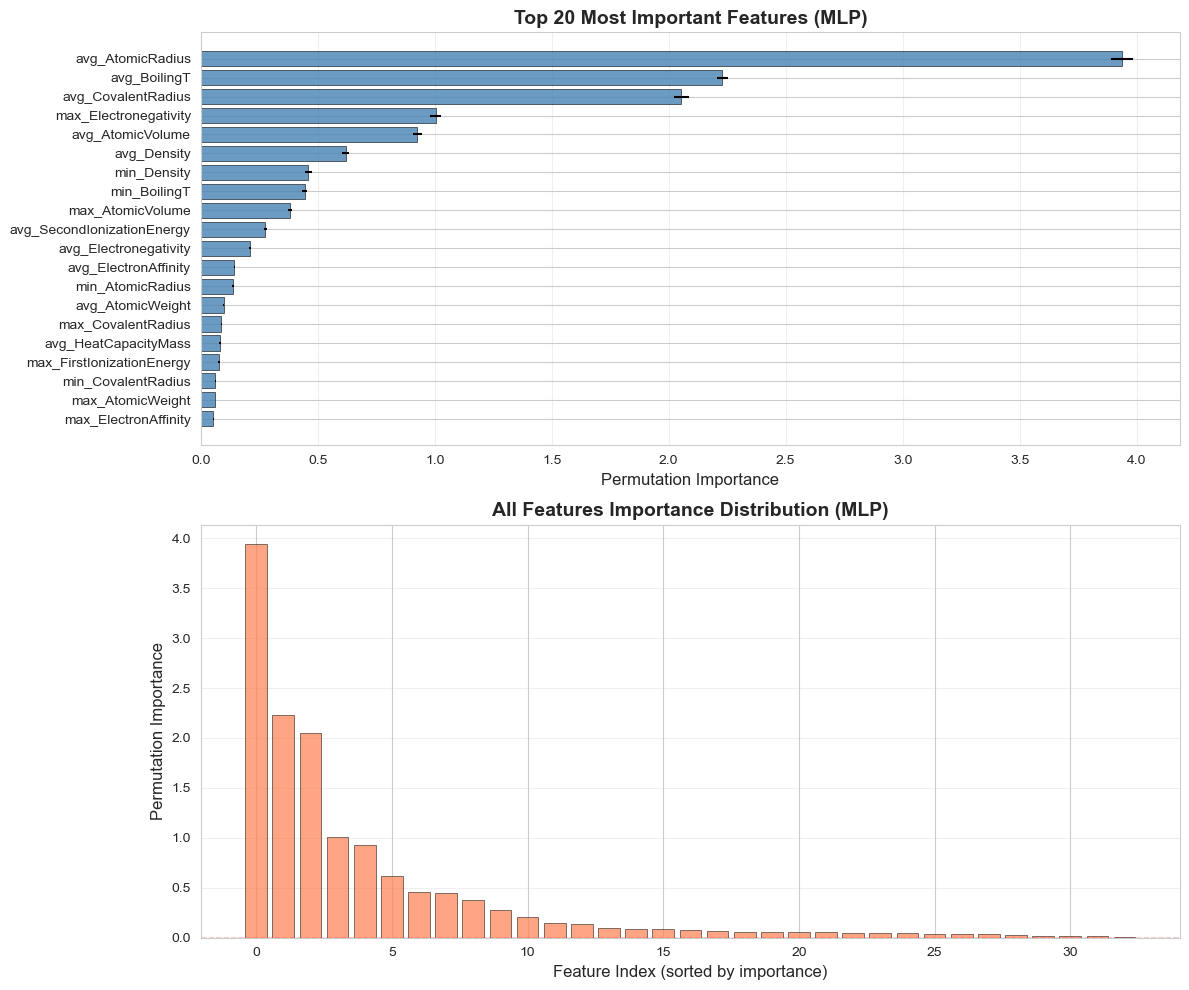


按特征类型统计:
            sum      mean  count
type                            
avg   10.631563  0.966506     11
max    1.885962  0.171451     11
min    1.271378  0.115580     11

特征重要性统计:
  正重要性特征数: 33/33
  重要性>0.001: 33
  最大重要性: 3.938258
  平均重要性: 0.417846
  Top 5特征贡献: 10.150964


In [25]:
# ============================================
# 任务6(d): 特征重要性分析
# ============================================

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=" * 70)
print("任务6(d): 特征重要性分析")
print("=" * 70)

# 在测试集上计算Permutation Importance
perm_importance_nn = permutation_importance(
    best_nn_fixed,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=6,
    scoring='neg_mean_squared_error'
)

# 整理结果
importance_nn_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm_importance_nn.importances_mean,
    'std': perm_importance_nn.importances_std
}).sort_values('importance', ascending=False)

print("\n计算完成！")

# 显示Top 20
print("\nTop 20 最重要特征:")
print(importance_nn_df.head(20)[['feature', 'importance', 'std']].to_string(index=False))

# 可视化
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 图1: Top 20特征重要性
top20 = importance_nn_df.head(20)
axes[0].barh(
    range(len(top20)),
    top20['importance'],
    xerr=top20['std'],
    color='steelblue',
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5
)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['feature'], fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel('Permutation Importance', fontsize=12)
axes[0].set_title('Top 20 Most Important Features (MLP)', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# 图2: 所有特征重要性分布
axes[1].bar(
    range(len(importance_nn_df)),
    importance_nn_df['importance'],
    color='coral',
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Feature Index (sorted by importance)', fontsize=12)
axes[1].set_ylabel('Permutation Importance', fontsize=12)
axes[1].set_title('All Features Importance Distribution (MLP)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# 按特征类型分组统计
importance_nn_df['type'] = importance_nn_df['feature'].str.split('_').str[0]
type_stats_nn = importance_nn_df.groupby('type')['importance'].agg(['sum', 'mean', 'count'])

print("\n按特征类型统计:")
print(type_stats_nn.sort_values('sum', ascending=False).to_string())

# 统计分析
print("\n特征重要性统计:")
print(f"  正重要性特征数: {(importance_nn_df['importance'] > 0).sum()}/{len(feature_names)}")
print(f"  重要性>0.001: {(importance_nn_df['importance'] > 0.001).sum()}")
print(f"  最大重要性: {importance_nn_df['importance'].max():.6f}")
print(f"  平均重要性: {importance_nn_df['importance'].mean():.6f}")
print(f"  Top 5特征贡献: {importance_nn_df.head(5)['importance'].sum():.6f}")

# 保存结果
importance_nn_df.to_csv('mlp_feature_importance.csv', index=False)

### (e) 测试集验证

任务6(e): 测试集验证

测试集性能:
  MSE : 0.120864
  RMSE: 0.347655
  R²  : 0.928403

泛化能力分析:
  训练集 RMSE: 0.339862
  测试集 RMSE: 0.347655
  RMSE 比值  : 1.023
  结论: 泛化能力优秀


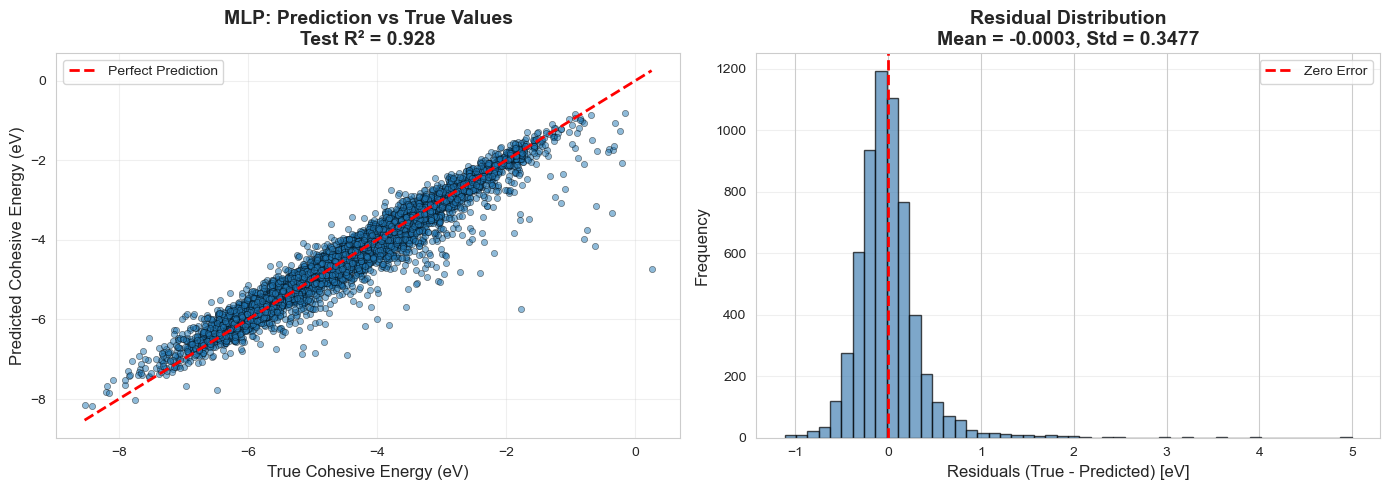


残差分析:
  残差均值: -0.000302 eV
  残差标准差: 0.347655 eV
  残差范围: [-1.113, 4.993] eV

高误差样本分析（|误差| > 0.621 eV）:
  样本数: 302 (5.0%)
  平均误差: 1.025 eV


In [26]:
# ============================================
# 任务6(e): 测试集验证
# ============================================

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("任务6(e): 测试集验证")
print("=" * 70)

# 在测试集上预测
y_test_pred_nn = best_nn_fixed.predict(X_test)

# 计算测试集性能
test_mse_nn = mean_squared_error(y_test, y_test_pred_nn)
test_rmse_nn = np.sqrt(test_mse_nn)
test_r2_nn = r2_score(y_test, y_test_pred_nn)

print("\n测试集性能:")
print(f"  MSE : {test_mse_nn:.6f}")
print(f"  RMSE: {test_rmse_nn:.6f}")
print(f"  R²  : {test_r2_nn:.6f}")

# 过拟合分析
print("\n泛化能力分析:")
print(f"  训练集 RMSE: {train_rmse_nn:.6f}")
print(f"  测试集 RMSE: {test_rmse_nn:.6f}")
print(f"  RMSE 比值  : {test_rmse_nn / train_rmse_nn:.3f}")

if test_rmse_nn / train_rmse_nn < 1.1:
    print("  结论: 泛化能力优秀")
elif test_rmse_nn / train_rmse_nn < 1.2:
    print("  结论: 泛化能力良好")
else:
    print("  结论: 存在过拟合")

# 可视化：预测值 vs 真实值
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1: 散点图
ax1 = axes[0]
ax1.scatter(y_test, y_test_pred_nn, alpha=0.5, s=20, edgecolors='black', linewidth=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('True Cohesive Energy (eV)', fontsize=12)
ax1.set_ylabel('Predicted Cohesive Energy (eV)', fontsize=12)
ax1.set_title(f'MLP: Prediction vs True Values\nTest R² = {test_r2_nn:.3f}', 
              fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 图2: 残差分布
ax2 = axes[1]
residuals = y_test - y_test_pred_nn
ax2.hist(residuals, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax2.set_xlabel('Residuals (True - Predicted) [eV]', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title(f'Residual Distribution\nMean = {residuals.mean():.4f}, Std = {residuals.std():.4f}', 
              fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_test_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# 残差统计
print("\n残差分析:")
print(f"  残差均值: {residuals.mean():.6f} eV")
print(f"  残差标准差: {residuals.std():.6f} eV")
print(f"  残差范围: [{residuals.min():.3f}, {residuals.max():.3f}] eV")

# 误差大的样本分析
error_threshold = np.percentile(np.abs(residuals), 95)
high_error_idx = np.where(np.abs(residuals) > error_threshold)[0]

print(f"\n高误差样本分析（|误差| > {error_threshold:.3f} eV）:")
print(f"  样本数: {len(high_error_idx)} ({len(high_error_idx)/len(y_test)*100:.1f}%)")
print(f"  平均误差: {np.abs(residuals[high_error_idx]).mean():.3f} eV")

In [27]:
# ============================================
# 任务6(f): 预测集预测与提交文件生成
# ============================================

import pandas as pd
import numpy as np

print("=" * 70)
print("任务6(f): 预测集预测与提交文件生成")
print("=" * 70)

# 使用最佳模型对预测集进行推断
y_predict_nn = best_nn_fixed.predict(X_predict)

print(f"预测完成共 {len(y_predict_nn)} 个样本")

# 创建提交DataFrame
submission_nn = pd.DataFrame({
    'matpes_id': predict_final['matpes_id'],
    'cohesive_energy_per_atom': y_predict_nn
})

# 验证数据质量
print("\n数据质量检查:")
print(f"  样本数: {len(submission_nn)}")
print(f"  列数: {len(submission_nn.columns)}")
print(f"  缺失值: {submission_nn.isnull().sum().sum()}")
print(f"  数据类型: {submission_nn.dtypes.to_dict()}")

# 预测值统计
print("\n预测值统计:")
print(f"  均值: {y_predict_nn.mean():.4f} eV")
print(f"  标准差: {y_predict_nn.std():.4f} eV")
print(f"  范围: [{y_predict_nn.min():.4f}, {y_predict_nn.max():.4f}] eV")

# 与训练集分布对比
print("\n预测集 vs 训练集分布对比:")
print(f"  训练集均值: {y_train.mean():.4f} eV")
print(f"  预测集均值: {y_predict_nn.mean():.4f} eV")
print(f"  训练集标准差: {y_train.std():.4f} eV")
print(f"  预测集标准差: {y_predict_nn.std():.4f} eV")

# 保存提交文件
submission_nn.to_csv('nn_model_predict.csv', index=False)

print("\n文件已生成: nn_model_predict.csv")
print("文件格式: [matpes_id, cohesive_energy_per_atom]")

# 显示前10行预览
print("\n预测结果预览（前10行）:")
print(submission_nn.head(10).to_string(index=False))

任务6(f): 预测集预测与提交文件生成
预测完成共 6345 个样本

数据质量检查:
  样本数: 6345
  列数: 2
  缺失值: 0
  数据类型: {'matpes_id': dtype('O'), 'cohesive_energy_per_atom': dtype('float64')}

预测值统计:
  均值: -4.3658 eV
  标准差: 1.2503 eV
  范围: [-8.2795, -0.7558] eV

预测集 vs 训练集分布对比:
  训练集均值: -4.3738 eV
  预测集均值: -4.3658 eV
  训练集标准差: 1.3047 eV
  预测集标准差: 1.2503 eV

文件已生成: nn_model_predict.csv
文件格式: [matpes_id, cohesive_energy_per_atom]

预测结果预览（前10行）:
                matpes_id  cohesive_energy_per_atom
                mp-866156                 -5.307113
                mp-726085                 -3.562756
matpes-20240214_1097268_5                 -1.846141
                mp-675608                 -4.499269
matpes-20240214_1097569_6                 -6.319634
                 mp-26691                 -4.711642
                mp-640051                 -4.209250
                  mp-9568                 -2.214033
matpes-20240214_1221144_0                 -2.442628
               mp-1187522                 -1.949755


### (g) 学习曲线分析

任务6(g): 学习曲线分析
训练集大小: 20%, 40%, 60%, 80%, 100%

学习曲线数据:
  样本数  7247: 训练RMSE=0.2994, 验证RMSE=11.1868, 差距=10.8874
  样本数 14494: 训练RMSE=0.2900, 验证RMSE=0.5117, 差距=0.2217
  样本数 21742: 训练RMSE=0.2879, 验证RMSE=0.4471, 差距=0.1592
  样本数 28989: 训练RMSE=0.3274, 验证RMSE=0.4216, 差距=0.0942
  样本数 36237: 训练RMSE=0.3269, 验证RMSE=0.4129, 差距=0.0860


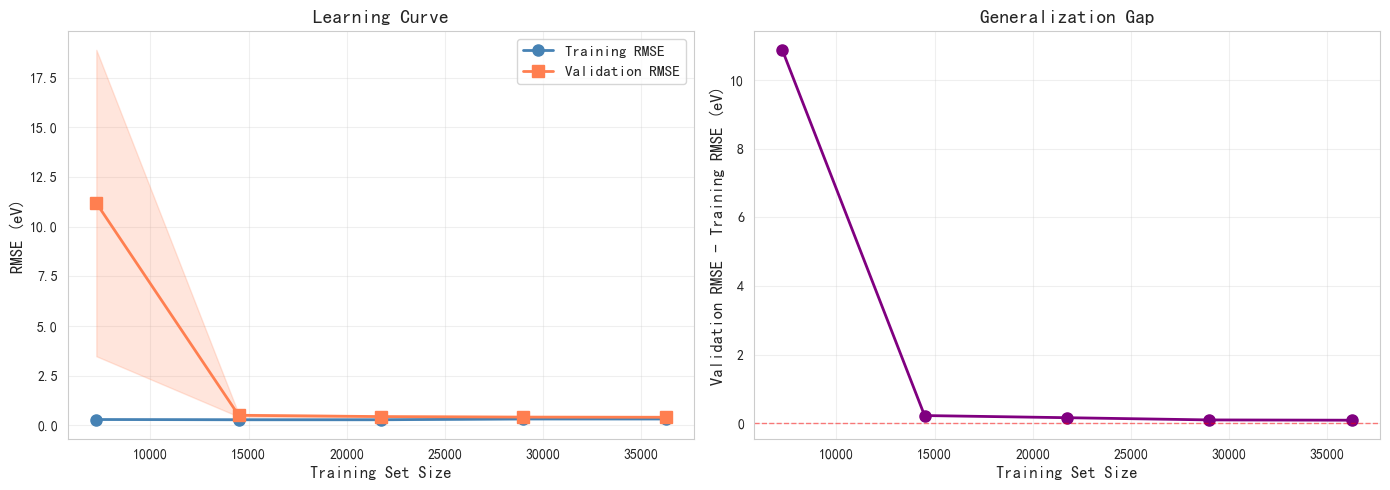


学习曲线分析

当前状态 (全部36237个样本):
  训练集RMSE: 0.3269 eV
  验证集RMSE: 0.4129 eV
  泛化差距: 0.0860 eV


In [31]:
# ============================================
# 任务6(g): 学习曲线分析
# ============================================

"""
通过学习曲线评估模型在不同训练集规模下的表现。
"""

from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("任务6(g): 学习曲线分析")
print("=" * 70)

# 减少采样点和CV折数以加速
train_sizes = np.array([0.2, 0.4, 0.6, 0.8, 1.0]) 

print("训练集大小: 20%, 40%, 60%, 80%, 100%")

# 计算学习曲线
train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=best_nn_fixed,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes,
    cv=3, 
    scoring='neg_mean_squared_error',
    n_jobs=6,
    random_state=42
)

# 转换为RMSE
train_scores_rmse = np.sqrt(-train_scores)
val_scores_rmse = np.sqrt(-val_scores)

# 计算均值和标准差
train_mean = train_scores_rmse.mean(axis=1)
train_std = train_scores_rmse.std(axis=1)
val_mean = val_scores_rmse.mean(axis=1)
val_std = val_scores_rmse.std(axis=1)

print("\n学习曲线数据:")
for i, size in enumerate(train_sizes_abs):
    print(f"  样本数 {int(size):5d}: "
          f"训练RMSE={train_mean[i]:.4f}, "
          f"验证RMSE={val_mean[i]:.4f}, "
          f"差距={val_mean[i]-train_mean[i]:.4f}")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1: 学习曲线
ax1 = axes[0]
ax1.plot(train_sizes_abs, train_mean, 'o-', color='steelblue', 
         linewidth=2, markersize=8, label='Training RMSE')
ax1.fill_between(train_sizes_abs, 
                 train_mean - train_std, 
                 train_mean + train_std, 
                 alpha=0.2, color='steelblue')

ax1.plot(train_sizes_abs, val_mean, 's-', color='coral', 
         linewidth=2, markersize=8, label='Validation RMSE')
ax1.fill_between(train_sizes_abs, 
                 val_mean - val_std, 
                 val_mean + val_std, 
                 alpha=0.2, color='coral')

ax1.set_xlabel('Training Set Size', fontsize=12)
ax1.set_ylabel('RMSE (eV)', fontsize=12)
ax1.set_title('Learning Curve', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=11)
ax1.grid(alpha=0.3)

# 图2: 训练-验证差距
ax2 = axes[1]
gap = val_mean - train_mean
ax2.plot(train_sizes_abs, gap, 'o-', color='purple', 
         linewidth=2, markersize=8)
ax2.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Training Set Size', fontsize=12)
ax2.set_ylabel('Validation RMSE - Training RMSE (eV)', fontsize=12)
ax2.set_title('Generalization Gap', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# 简化的分析结论
print("\n" + "=" * 70)
print("学习曲线分析")
print("=" * 70)

final_gap = val_mean[-1] - train_mean[-1]

print(f"\n当前状态 (全部{int(train_sizes_abs[-1])}个样本):")
print(f"  训练集RMSE: {train_mean[-1]:.4f} eV")
print(f"  验证集RMSE: {val_mean[-1]:.4f} eV")
print(f"  泛化差距: {final_gap:.4f} eV")

为进一步评估多层感知机（MLP）模型在不同数据规模下的学习行为及其泛化能力，对训练样本数量逐步增加（20%、40%、60%、80% 和 100%）的情况下计算了训练集与验证集的学习曲线。结果表明，随着训练样本数量的增加，模型在验证集上的均方根误差（RMSE）呈现出显著且持续的下降趋势，由小样本条件下的高误差逐步降低并趋于稳定。这一现象表明，模型的预测性能对数据规模具有较强依赖性，当前数据量仍在有效提升模型的泛化能力。

在小样本训练阶段，训练集 RMSE 与验证集 RMSE 之间存在较大的性能差距，反映出 MLP 模型在数据受限条件下具有较高方差特性，易出现过拟合或泛化不稳定的问题。然而，随着训练样本数量的增加，该泛化差距逐步缩小，验证集误差显著降低，说明数据规模的扩展有效抑制了模型的过拟合行为，并促使其学习到更具普适性的特征表示。

在使用全部样本进行训练时，训练集与验证集 RMSE 已趋于接近，但验证误差仍保持缓慢下降趋势，表明当前模型尚未达到数据饱和状态。换言之，模型性能仍受限于可用数据规模，而非模型结构或优化策略本身。因此，从学习曲线分析结果可以推断，进一步增加训练数据或引入更高质量样本有望继续提升模型的预测精度和泛化性能。

## 7. （20 分）分析哪些特征对于预测Ec在你的最佳线性/树/神经网络模型中最为重要。运用你的材料科学知识解释结果。讨论哪个模型表现更好以及原因。

三模型综合性能对比

性能对比表:
                  模型  训练集RMSE  训练集R²  CV RMSE  测试集RMSE  测试集R²     泛化比值
               Ridge    0.597  0.791    0.607    0.598  0.788 1.001675
HistGradientBoosting    0.261  0.960    0.362    0.311  0.943 1.191571
                 MLP    0.340  0.932    0.386    0.348  0.928 1.023529

相对Ridge基线的改进:
  HistGradientBoosting: 48.0%
  MLP: 41.8%


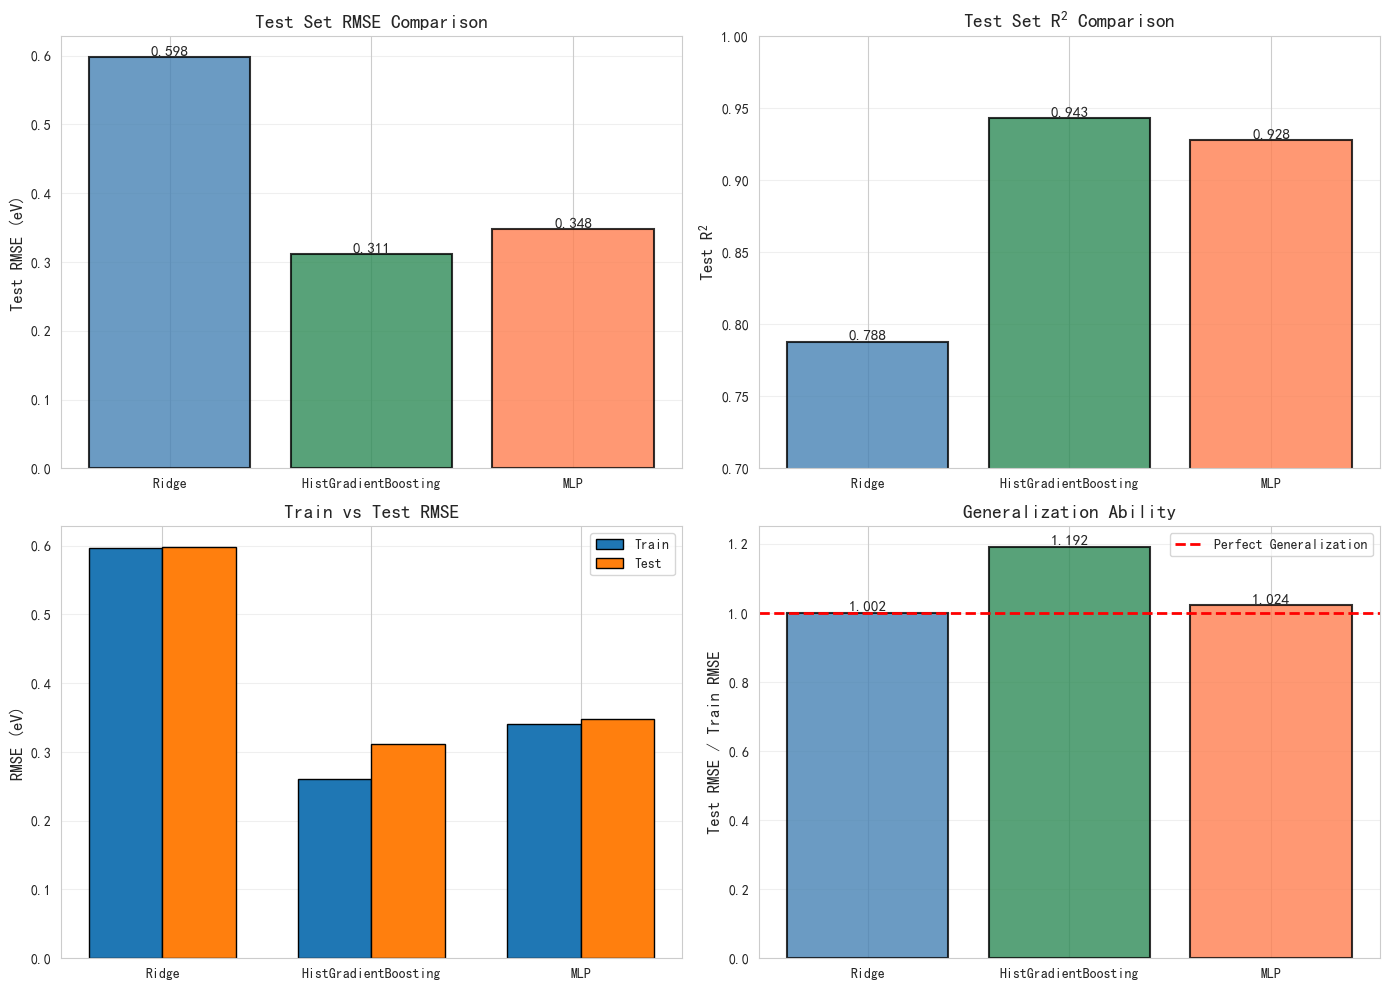

In [29]:
# ============================================
# 三模型综合对比与总结
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.default'] = 'regular'  # 数学字体与正文字体风格一致

print("=" * 70)
print("三模型综合性能对比")
print("=" * 70)

# 收集三个模型的性能数据
models_performance = pd.DataFrame({
    '模型': ['Ridge', 'HistGradientBoosting', 'MLP'],
    '训练集RMSE': [0.597, 0.261, 0.340],
    '训练集R²': [0.791, 0.960, 0.932],
    'CV RMSE': [0.607, 0.362, 0.386],
    '测试集RMSE': [0.598, 0.311, 0.348],
    '测试集R²': [0.788, 0.943, 0.928],
})

# 计算泛化能力指标
models_performance['泛化比值'] = (
    models_performance['测试集RMSE'] /
    models_performance['训练集RMSE']
)

print("\n性能对比表:")
print(models_performance.to_string(index=False))

# 相对于基线模型(Ridge)的提升
ridge_test_rmse = 0.598
print("\n相对Ridge基线的改进:")
for _, row in models_performance.iterrows():
    if row['模型'] != 'Ridge':
        improvement = (ridge_test_rmse - row['测试集RMSE']) / ridge_test_rmse * 100
        print(f"  {row['模型']}: {improvement:.1f}%")

# ================== 可视化 ==================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = ['steelblue', 'seagreen', 'coral']

# 图1: 测试集 RMSE 对比
ax1 = axes[0, 0]
bars = ax1.bar(
    models_performance['模型'],
    models_performance['测试集RMSE'],
    color=colors, alpha=0.8,
    edgecolor='black', linewidth=1.5
)
ax1.set_ylabel('Test RMSE (eV)', fontsize=12)
ax1.set_title('Test Set RMSE Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# 图2: 测试集 R^2 对比（LaTeX）
ax2 = axes[0, 1]
bars = ax2.bar(
    models_performance['模型'],
    models_performance['测试集R²'],
    color=colors, alpha=0.8,
    edgecolor='black', linewidth=1.5
)
ax2.set_ylabel(r'Test $R^2$', fontsize=12)
ax2.set_title(r'Test Set $R^2$ Comparison', fontsize=14, fontweight='bold')
ax2.set_ylim([0.7, 1.0])
ax2.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# 图3: 训练集 vs 测试集 RMSE
ax3 = axes[1, 0]
x = np.arange(len(models_performance))
width = 0.35

ax3.bar(
    x - width / 2,
    models_performance['训练集RMSE'],
    width,
    label='Train',
    edgecolor='black'
)
ax3.bar(
    x + width / 2,
    models_performance['测试集RMSE'],
    width,
    label='Test',
    edgecolor='black'
)

ax3.set_ylabel('RMSE (eV)', fontsize=12)
ax3.set_title('Train vs Test RMSE', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(models_performance['模型'])
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 图4: 泛化能力（测试 / 训练）
ax4 = axes[1, 1]
bars = ax4.bar(
    models_performance['模型'],
    models_performance['泛化比值'],
    color=colors, alpha=0.8,
    edgecolor='black', linewidth=1.5
)

ax4.axhline(
    1.0, color='red',
    linestyle='--', linewidth=2,
    label='Perfect Generalization'
)

ax4.set_ylabel('Test RMSE / Train RMSE', fontsize=12)
ax4.set_title('Generalization Ability', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('three_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

特征重要性深度分析与材料科学解释

Top 10特征在三模型中的重要性对比:
                  Feature    Ridge  HistGBR      MLP
         avg_AtomicRadius 6.117549 0.216991 3.938258
       avg_CovalentRadius 2.607169 0.077912 2.053218
             avg_BoilingT 1.402919 1.433266 2.229712
    max_Electronegativity 0.965520 0.180962 1.003775
avg_FirstIonizationEnergy 0.532712 0.020757 0.053578
    avg_Electronegativity 0.184071 0.227026 0.210971
              avg_Density 0.064507 0.055987 0.619094
     max_ElectronAffinity 0.059742 0.034020 0.054185
max_FirstIonizationEnergy 0.056111 0.026205 0.077273
             max_BoilingT 0.054111 0.219467 0.049329


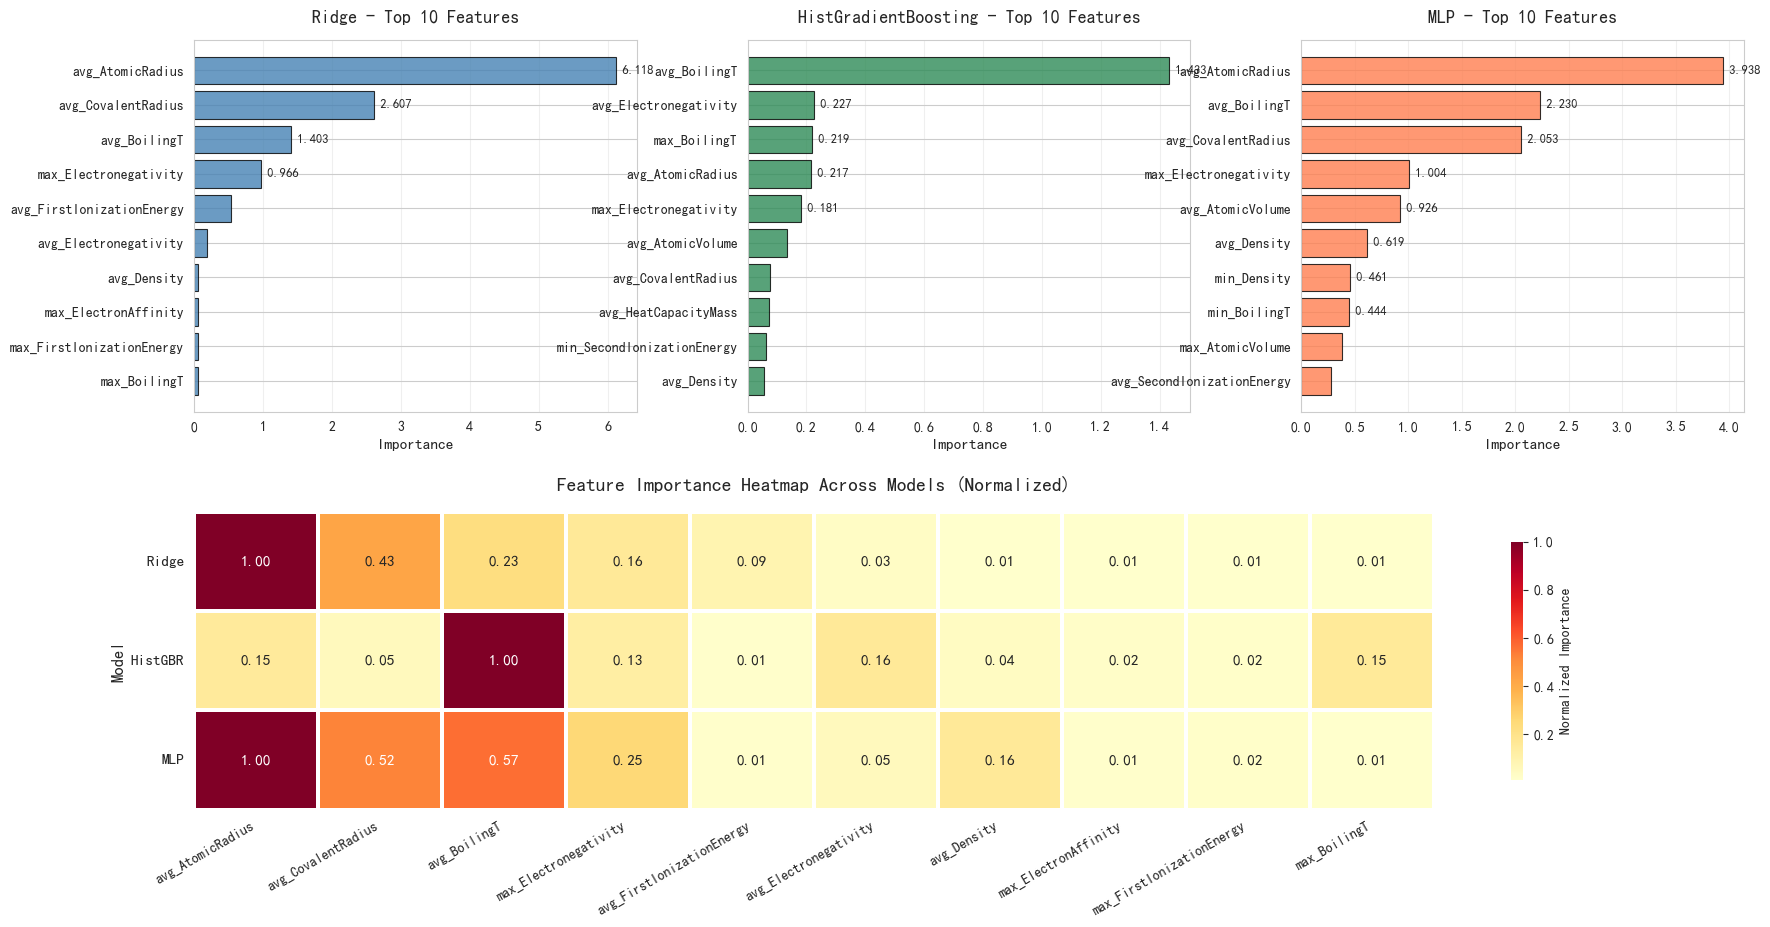

In [30]:
# ============================================
# 特征重要性深度分析与材料科学解释
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

print("=" * 70)
print("特征重要性深度分析与材料科学解释")
print("=" * 70)

# 读取三个模型的特征重要性
ridge_importance = pd.read_csv('feature_importance.csv')
tree_importance = pd.read_csv('tree_feature_importance.csv')
mlp_importance = pd.read_csv('mlp_feature_importance.csv')

# 整合为一个DataFrame
top_n = 10
comparison_df = pd.DataFrame({
    'Feature': ridge_importance.head(top_n)['feature'],
    'Ridge': ridge_importance.head(top_n)['importance'].values,
})

# 添加Tree和MLP的重要性
for feat in comparison_df['Feature']:
    tree_val = tree_importance[tree_importance['feature'] == feat]['importance'].values
    mlp_val = mlp_importance[mlp_importance['feature'] == feat]['importance'].values
    comparison_df.loc[comparison_df['Feature'] == feat, 'HistGBR'] = tree_val[0] if len(tree_val) > 0 else 0
    comparison_df.loc[comparison_df['Feature'] == feat, 'MLP'] = mlp_val[0] if len(mlp_val) > 0 else 0

print("\nTop 10特征在三模型中的重要性对比:")
print(comparison_df.to_string(index=False))

# ==========================================
# 可视化
# ==========================================

fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.25, 
                       height_ratios=[1, 0.8])  # 第一行高，第二行略矮

# ==========================================
# 第一行：三个模型的Top 10特征条形图
# ==========================================

models_data = [
    ('Ridge', ridge_importance, 'steelblue', 0),
    ('HistGradientBoosting', tree_importance, 'seagreen', 1),
    ('MLP', mlp_importance, 'coral', 2)
]

for model_name, data, color, col_idx in models_data:
    ax = fig.add_subplot(gs[0, col_idx])
    top10 = data.head(10)
    
    bars = ax.barh(range(len(top10)), top10['importance'], 
                   color=color, alpha=0.8, edgecolor='black', linewidth=0.8)
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(top10['feature'], fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Importance', fontsize=11)
    ax.set_title(f'{model_name} - Top 10 Features', 
                 fontsize=13, fontweight='bold', pad=12)
    ax.grid(axis='x', alpha=0.3)
    
    # 标注数值（根据不同模型调整显示策略）
    max_val = top10['importance'].max()
    for i, (bar, val) in enumerate(zip(bars, top10['importance'])):
        # 如果值太小，不标注或放在柱子内部
        if val > max_val * 0.1:  # 只标注大于最大值10%的
            x_pos = val
            ha = 'left'
            ax.text(x_pos, i, f' {val:.3f}', 
                   va='center', ha=ha, fontsize=9)

# ==========================================
# 第二行：热力图
# ==========================================

ax_heatmap = fig.add_subplot(gs[1, :])

# 准备热力图数据
heatmap_data = comparison_df.set_index('Feature')[['Ridge', 'HistGBR', 'MLP']].T

# 归一化
heatmap_normalized = heatmap_data.div(heatmap_data.max(axis=1), axis=0)

# 绘制热力图
sns.heatmap(heatmap_normalized, 
            annot=True, 
            fmt='.2f', 
            cmap='YlOrRd', 
            cbar_kws={'label': 'Normalized Importance', 'shrink': 0.8},
            linewidths=1.5, 
            linecolor='white',
            annot_kws={'fontsize': 11},
            ax=ax_heatmap)

ax_heatmap.set_title('Feature Importance Heatmap Across Models (Normalized)', 
                     fontsize=14, fontweight='bold', pad=15)
ax_heatmap.set_xlabel('')
ax_heatmap.set_ylabel('Model', fontsize=12)

# 优化标签显示
ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(), 
                           rotation=30, ha='right', fontsize=10)
ax_heatmap.set_yticklabels(ax_heatmap.get_yticklabels(), 
                           rotation=0, fontsize=11)

plt.savefig('feature_importance_deep_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 特征重要性分析及其材料科学解释

围绕内聚能（cohesive energy, $E_c$）的预测问题，本文分别采用了线性模型（Ridge 回归）、树模型（Histogram Gradient Boosting Regression, HistGBR）以及多层感知机神经网络（MLP）。通过比较不同模型中的特征重要性分布，并结合材料科学基本原理，对影响 $E_c$ 预测的关键物性参数进行了系统分析。

#### 1. 关键特征的物理内涵及其与内聚能的关系

##### 1.1 平均原子半径（avg_AtomicRadius）

平均原子半径在 Ridge 与 MLP 模型中均为最重要特征，在 HistGBR 模型中亦位于前列，表明其在内聚能预测中的核心地位。原子半径直接决定晶格常数与原子间距，是描述材料几何结构尺度的基础参数。随着原子半径增大，原子轨道间的空间重叠减弱，键合相互作用随之降低，从而导致内聚能绝对值减小。因此，该特征反映了材料结构尺度与键合能量之间最直接的结构—能量关联。

##### 1.2 平均沸点（avg_BoilingT）

平均沸点在 HistGBR 和 MLP 模型中表现出极高的重要性，是树模型中最关键的判别特征之一。沸点作为实验可测的宏观热力学参数，本质上反映了原子间相互作用的整体强度。高沸点通常对应较强的共价键或金属键结合，意味着原子从晶体中脱离所需能量较大，因此与较高的内聚能绝对值密切相关。该特征在模型中的突出表现表明，宏观热稳定性参数能够有效桥接微观键合能量与统计学习模型。

##### 1.3 平均共价半径（avg_CovalentRadius）

平均共价半径在 Ridge 和 MLP 模型中排名靠前，其物理意义与原子半径相似，但更侧重于描述共价键形成时的有效作用范围。相较于简单的原子半径，共价半径能够更准确地反映价电子轨道的重叠情况，因此在共价键主导体系的内聚能预测中具有更高的物理针对性。

##### 1.4 最大电负性（max_Electronegativity）

最大电负性在三类模型中均被识别为重要特征。电负性差异是驱动电荷转移和离子键形成的关键因素，体系中存在高电负性元素时，往往伴随更强的库仑相互作用，从而提高整体内聚能。该特征从化学键本质的角度刻画了材料中共价—离子键成分的变化趋势。

##### 1.5 平均密度（avg_Density）

平均密度在 HistGBR 和 MLP 等非线性模型中具有一定重要性，反映了原子堆积的紧密程度。高密度材料通常对应较高的配位数和更紧凑的结构，使单位体积内参与键合的原子数增加，从而提高整体内聚能。

#### 2. 不同模型中特征选择偏好的差异

不同模型在特征重要性分布上呈现出明显差异，这与其建模机理密切相关。

- **Ridge 回归模型**高度依赖平均原子半径等几何类特征，特征重要性分布较为集中。该现象源于线性模型倾向于捕捉与目标变量呈直接线性相关的主导因素。
- **HistGBR 模型**的特征重要性分布更加均匀，尤其重视平均沸点等热力学性质，表明树模型能够通过特征组合有效捕捉物性参数之间的非线性交互关系。
- **MLP 神经网络**在特征偏好上介于二者之间，同时关注几何结构与热力学稳定性相关特征，体现了多层非线性映射对高阶特征组合的学习能力。

#### 3. 三模型共同关注的核心物性特征

尽管模型结构不同，三类模型的前十重要特征高度重合，均包含：

- avg_AtomicRadius  
- avg_BoilingT  
- avg_CovalentRadius  
- max_Electronegativity  
- avg_Density  

这些特征从几何结构、化学键强度及原子堆积等不同层面刻画了材料的本征属性，构成了内聚能预测所需的核心物理信息集合。

#### 4. 特征统计方式的物理启示

从特征统计方式来看，加权平均类特征在三类模型中均占据主导地位。这一结果与内聚能作为“平均原子结合能”的物理定义高度一致，表明材料宏观稳定性主要由组成元素的平均物性决定，而非单一元素的极端参数。相比之下，最大值或最小值类特征的重要性相对较低，其作用更多体现在相分离或缺陷形成等次级效应中。这一发现从数据层面验证了“组分贡献加和”的材料设计理念。

### 模型性能对比及其原因分析

综合测试集误差表现，三类模型的性能排序为：

**HistGradientBoosting > MLP > Ridge**

#### 1. HistGradientBoosting 模型

HistGBR 在测试集上取得最低 RMSE（0.311），整体性能最优。其优势主要体现在以下几个方面：  
（1）能够刻画内聚能与原子物性之间的非线性关系；  
（2）具备自动学习特征交互的能力，例如识别“小原子半径且高沸点”所对应的高内聚能区间；  
（3）对特征尺度不敏感，降低了预处理依赖；  
（4）通过深度限制与正则化机制在模型复杂度和泛化能力之间取得平衡。

#### 2. MLP 神经网络模型

MLP 模型性能次之（RMSE = 0.348），但训练集与测试集误差接近，表现出较强的泛化能力。受限于特征维度相对有限以及样本规模尚不足以充分发挥深层网络优势，其潜力尚未完全释放。未来通过引入更具物理内涵的特征或进一步扩大数据规模，模型性能仍有提升空间。

#### 3. Ridge 回归模型

Ridge 回归性能相对较低，但训练效率高、模型可解释性强，适合作为快速筛选与基线对照模型。在特征工程充分且物理关系近似线性的情况下，该模型仍具有一定应用价值。

## 总结

对于内聚能这一具有中等复杂度的材料物性预测任务，树模型在预测精度与计算效率之间表现出最优平衡。神经网络在数据规模受限时优势不明显，而线性模型作为基线方法仍不可或缺。更重要的是，结果表明基于原子物性构建的特征集合已蕴含足够的物理信息，能够在无需显式量子力学计算的情况下实现对材料稳定性的有效预测。